# ⚡ Zone 1 Power Consumption Forecasting: Predictive Analytics for Energy Management

---

## 🎯 Business Objective

### **Problem Statement**
Develop a robust predictive model to forecast power consumption in Zone 1 of Tetouan City's distribution network, enabling optimized energy allocation, cost reduction, and improved grid stability.

### **Key Business Value**
- **Energy Optimization:** Reduce operational costs through better load forecasting
- **Infrastructure Planning:** Support capacity planning and maintenance scheduling
- **Sustainability:** Minimize energy waste through accurate demand prediction
- **Cost Efficiency:** Enable dynamic pricing strategies and peak load management

---

## 📊 Dataset Overview

### **Source**
**UCI Machine Learning Repository**  
🔗 [Power Consumption of Tetouan City Dataset](https://archive.ics.uci.edu/dataset/849/power+consumption+of+tetouan+city)

### **Dataset Characteristics**
- **Temporal Resolution:** 10-minute intervals
- **Coverage:** Three distribution networks in Tetouan City, Morocco
- **Period:** Comprehensive time-series data
- **Records:** ~52,000 observations (1 year at 10-minute intervals)

### **Feature Schema**
| Variable | Type | Description | Unit |
|----------|------|-------------|------|
| `DateTime` | Temporal | Timestamp (10-min intervals) | DateTime |
| `Temperature` | Continuous | Ambient temperature | °C |
| `Humidity` | Continuous | Relative humidity | % |
| `Wind Speed` | Continuous | Wind velocity | km/h |
| `General Diffuse Flows` | Continuous | General diffuse energy flows | kW |
| `Diffuse Flows` | Continuous | Specific diffuse flows | kW |
| `PowerConsumption_Zone1` | **Target** | Zone 1 consumption | kW |
| `PowerConsumption_Zone2` | Continuous | Zone 2 consumption | kW |
| `PowerConsumption_Zone3` | Continuous | Zone 3 consumption | kW |

---

## 🧪 Technical Framework

### **Problem Classification**
- **Type:** Multivariate Time Series Regression
- **Target:** Continuous numerical prediction of `PowerConsumption_Zone1`
- **Approach:** Supervised machine learning with temporal features

### **Success Metrics**
- **Primary:** RMSE (Root Mean Square Error)
- **Secondary:** MAE (Mean Absolute Error), R² Score
- **Business:** Forecasting accuracy for operational decision-making

---

## 📋 Project Roadmap

### **Phase 1: Problem Framing & Data Understanding**
- Target variable definition: `PowerConsumption_Zone1`
- Regression problem specification
- Baseline model establishment
- Exploratory data analysis framework

### **Phase 2: Feature Engineering & Preprocessing**
- Temporal feature extraction (hour, day, seasonality)
- Weather variable transformation
- Lag feature creation
- Data normalization strategies

### **Phase 3: Model Development & Validation**
- Multiple algorithm benchmarking
- Cross-validation with temporal splits
- Hyperparameter optimization
- Ensemble method evaluation

### **Phase 4: Deployment & Monitoring**
- Model performance tracking
- Production deployment pipeline
- Continuous learning implementation

---

## 📚 Academic Reference

**Research Citation:**  
Salam, A., & El Hibaoui, A. (2018). *Comparison of Machine Learning Algorithms for the Power Consumption Prediction: Case Study of Tetouan city*. In 2018 6th International Renewable and Sustainable Energy Conference (IRSEC) (pp. 1-5). IEEE.

**DOI:** [10.1109/IRSEC.2018.8703007](https://doi.org/10.1109/IRSEC.2018.8703007)

---

## 🎯 Immediate Next Steps

### **Current Phase: Problem Framing ✅**
- **Target Variable:** `PowerConsumption_Zone1` 
- **Problem Type:** Multivariate Time Series Regression
- **Evaluation Framework:** Established

### **Ready for Phase 2:** Data Loading & Exploratory Analysis

---

*This project demonstrates professional energy analytics implementation with clear business impact and technical rigor.*

In [1]:
# ===============================
# STEP 1: IMPORT & INITIAL INSPECTION
# ===============================

# Standard library imports
import os
from pathlib import Path
import sys
import warnings
from datetime import datetime, timedelta
from typing import List, Dict, Tuple, Optional

# Third-party imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
# LOAD DATASET WITH ERROR HANDLING


## PANDAS AND SEABORN CONFIGURATION SETTINGS

In [2]:
# SET THE OPTIONS FOR PANDAS AND SEABORN


pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
#Display data in 2 decimal place
pd.options.display.float_format = '{:20.2f}'.format
# Set the style of seaborn
sns.set(style="whitegrid")

# Configuration
warnings.filterwarnings('ignore')



In [3]:

DATA_FOLDER = r"G:\Study\DATA SCINCE\PROJECTS\POTFOLIO\Power Consumption Forecasting with Predictive Analytics\data"
FILE_NAME = "powerconsumption.csv"
FILE_PATH = Path(DATA_FOLDER) / FILE_NAME

try:
    print(" Loading dataset to inspect column names...")
    
    # First load without date parsing to see actual columns
    df = pd.read_csv(FILE_PATH)
    
    print(" Actual columns in your dataset:")
    print("=" * 40)
    for i, col in enumerate(df.columns, 1):
        print(f"{i}. {col}")
    
    print(f"\n Shape: {df.shape}")
    print(f" First 3 rows:")
    display(df.head(3))
    
    # Now check which column looks like datetime
    print("\n Checking for datetime column...")
    for col in df.columns:
        sample_value = str(df[col].iloc[0]) if len(df) > 0 else "N/A"
        print(f"'{col}': {sample_value} (dtype: {df[col].dtype})")

    print('\n Checking  dupllicates')
    display(df[df.duplicated()])

    print('\n Checking Missing values')
    missing = df.isna().sum().to_frame(name='Missing_Values')
    missing['Missing %'] = (missing['Missing_Values'] / len(df) * 100)
    display(missing.sort_values(by='Missing %',ascending=False))
    
except Exception as e:
    print(f" Error: {e}")

 Loading dataset to inspect column names...
 Actual columns in your dataset:
1. Datetime
2. Temperature
3. Humidity
4. WindSpeed
5. GeneralDiffuseFlows
6. DiffuseFlows
7. PowerConsumption_Zone1
8. PowerConsumption_Zone2
9. PowerConsumption_Zone3

 Shape: (52416, 9)
 First 3 rows:


,Datetime,Temperature,Humidity,WindSpeed,GeneralDiffuseFlows,DiffuseFlows,PowerConsumption_Zone1,PowerConsumption_Zone2,PowerConsumption_Zone3
0,2017-01-01 00:00:00,6.56,73.80,0.08,0.05,0.12,34055.70,16128.88,20240.96
1,2017-01-01 00:10:00,6.41,74.50,0.08,0.07,0.09,29814.68,19375.08,20131.08
2,2017-01-01 00:20:00,6.31,74.50,0.08,0.06,0.10,29128.10,19006.69,19668.43



 Checking for datetime column...
'Datetime': 2017-01-01 00:00:00 (dtype: object)
'Temperature': 6.559 (dtype: float64)
'Humidity': 73.8 (dtype: float64)
'WindSpeed': 0.083 (dtype: float64)
'GeneralDiffuseFlows': 0.051 (dtype: float64)
'DiffuseFlows': 0.119 (dtype: float64)
'PowerConsumption_Zone1': 34055.6962 (dtype: float64)
'PowerConsumption_Zone2': 16128.87538 (dtype: float64)
'PowerConsumption_Zone3': 20240.96386 (dtype: float64)

 Checking  dupllicates


,Datetime,Temperature,Humidity,WindSpeed,GeneralDiffuseFlows,DiffuseFlows,PowerConsumption_Zone1,PowerConsumption_Zone2,PowerConsumption_Zone3



 Checking Missing values


,Missing_Values,Missing %
Datetime,0,0.00
Temperature,0,0.00
Humidity,0,0.00
WindSpeed,0,0.00
GeneralDiffuseFlows,0,0.00
DiffuseFlows,0,0.00
PowerConsumption_Zone1,0,0.00
PowerConsumption_Zone2,0,0.00
PowerConsumption_Zone3,0,0.00


## 🕒 Datetime Format Issue

The datetime column in the dataset is not in the correct format.  
We need to convert it to a proper datetime type for accurate analysis and feature engineering.

In [4]:
# ===============================
# STEP 2: UNDERSTAND DATETIME STRUCTURE
# ===============================
print("\n STEP 2: DATETIME ANALYSIS")
print("="*50)

# 2.1 Check for datetime columns
datetime_cols = [col for col in df.columns if 'date' in col.lower() or 'time' in col.lower()]
print(f"Datetime columns found: {datetime_cols}")

if datetime_cols:
    # Convert to datetime
    df[datetime_cols[0]] = pd.to_datetime(df[datetime_cols[0]])
    df = df.sort_values(datetime_cols[0])
    
    # Extract time features
    df['Year'] = df[datetime_cols[0]].dt.year
    df['Month'] = df[datetime_cols[0]].dt.month  
    df['Day'] = df[datetime_cols[0]].dt.day
    df['Hour'] = df[datetime_cols[0]].dt.hour
    df['DayOfWeek'] = df[datetime_cols[0]].dt.dayofweek
    
    print(" Datetime processed and features extracted")
else:
    print(" No datetime column found - check your data")


 STEP 2: DATETIME ANALYSIS
Datetime columns found: ['Datetime']
 Datetime processed and features extracted


In [5]:


def enhanced_stats_info(dataframe):
    """
    Enhanced version of your original Stats_info function with better formatting and insights
    """
    
    print(" DATASET STATISTICAL SUMMARY")
    print("=" * 60)
    
    # Numerical Statistics
    numerical_cols = dataframe.select_dtypes(include=['number']).columns
    if len(numerical_cols) > 0:
        print("\n NUMERICAL FEATURES")
        print("-" * 30)
        numerical_stats = dataframe[numerical_cols].describe().T
        numerical_stats['variance'] = dataframe[numerical_cols].var()
        display(numerical_stats)
    else:
        print("No numerical features found.")
    
    # Categorical Statistics
    categorical_cols = dataframe.select_dtypes(include=['object', 'category']).columns
    if len(categorical_cols) > 0:
        print("\n CATEGORICAL FEATURES")
        print("-" * 30)
        cat_stats = dataframe[categorical_cols].describe().T
        display(cat_stats)
    else:
        print("No categorical features found.")
    

# Execute the function
enhanced_stats_info(df)

 DATASET STATISTICAL SUMMARY

 NUMERICAL FEATURES
------------------------------


,count,mean,std,min,25%,50%,75%,max,variance
Temperature,52416.00,18.81,5.82,3.25,14.41,18.78,22.89,40.01,33.82
Humidity,52416.00,68.26,15.55,11.34,58.31,69.86,81.40,94.80,241.84
WindSpeed,52416.00,1.96,2.35,0.05,0.08,0.09,4.92,6.48,5.52
GeneralDiffuseFlows,52416.00,182.70,264.40,0.00,0.06,5.04,319.60,1163.00,69907.87
DiffuseFlows,52416.00,75.03,124.21,0.01,0.12,4.46,101.00,936.00,15428.36
PowerConsumption_Zone1,52416.00,32344.97,7130.56,13895.70,26310.67,32265.92,37309.02,52204.40,50844922.48
PowerConsumption_Zone2,52416.00,21042.51,5201.47,8560.08,16980.77,20823.17,24713.72,37408.86,27055247.43
PowerConsumption_Zone3,52416.00,17835.41,6622.17,5935.17,13129.33,16415.12,21624.10,47598.33,43853070.60
Year,52416.00,2017.00,0.00,2017.00,2017.00,2017.00,2017.00,2017.00,0.00
Month,52416.00,6.51,3.44,1.00,4.00,7.00,9.25,12.00,11.84


No categorical features found.


### ✅ Converting `Datetime` column to correct dtype in Pandase

## 📊 Data Split: Chronological / Time-Based Split

### ✅ What it is:
- A **chronological split** divides your dataset based on **time order**.
- Earlier data → **Train set**  
- Later data → **Test set**  

### ✅ Why we use it:
- Ensures the model **does not see future data** during training.  
- Perfect for **time series or sequential data**, e.g.:  
  - Power consumption forecasting  


In [6]:
# Chronological split on the full dataset
split_index = int(len(df) * 0.8)

train_data = df.iloc[:split_index].copy()
test_data  = df.iloc[split_index:].copy()
print(f"Train shape: {train_data.shape}, Test shape: {test_data.shape}")



Train shape: (41932, 14), Test shape: (10484, 14)


# 🧩 Exploratory Data Analysis (EDA)

In [7]:
# Set style and palette
sns.set_style('darkgrid')
palette = sns.color_palette("tab10")
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.facecolor'] = 'white'  # Ensure figure background is white for darkgrid

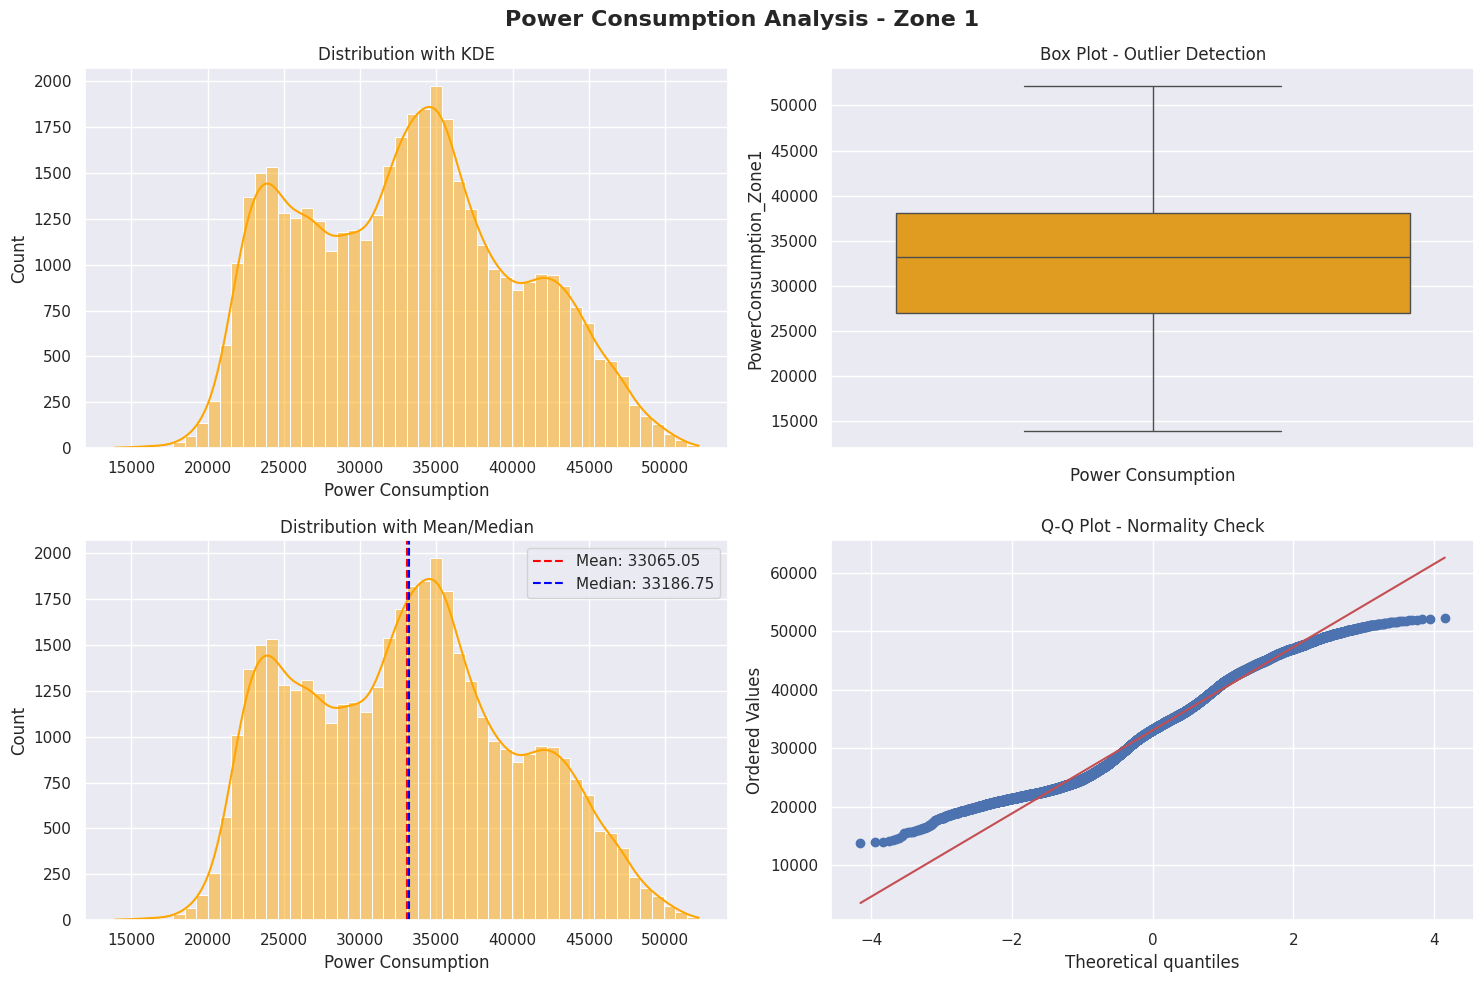

In [8]:
# If you prefer to work directly with train_data without creating y_train
target_column = 'PowerConsumption_Zone1'  # Adjust to your column name

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Power Consumption Analysis - Zone 1', fontsize=16, fontweight='bold')

# Original distribution
sns.histplot(train_data[target_column], bins=50, kde=True, color='orange', ax=axes[0,0])
axes[0,0].set_title("Distribution with KDE")
axes[0,0].set_xlabel("Power Consumption")

# Box plot for outliers
sns.boxplot(y=train_data[target_column], color='orange', ax=axes[0,1])
axes[0,1].set_title("Box Plot - Outlier Detection")
axes[0,1].set_xlabel("Power Consumption")

# Distribution with statistical annotations
sns.histplot(train_data[target_column], bins=50, kde=True, color='orange', ax=axes[1,0])
mean_val = train_data[target_column].mean()
median_val = train_data[target_column].median()
axes[1,0].axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}')
axes[1,0].axvline(median_val, color='blue', linestyle='--', label=f'Median: {median_val:.2f}')
axes[1,0].legend()
axes[1,0].set_title("Distribution with Mean/Median")
axes[1,0].set_xlabel("Power Consumption")

# QQ plot for normality check
from scipy import stats
stats.probplot(train_data[target_column], dist="norm", plot=axes[1,1])
axes[1,1].set_title("Q-Q Plot - Normality Check")

plt.tight_layout()
plt.show()

\Average Consumption


np.float64(19270.842659435537)

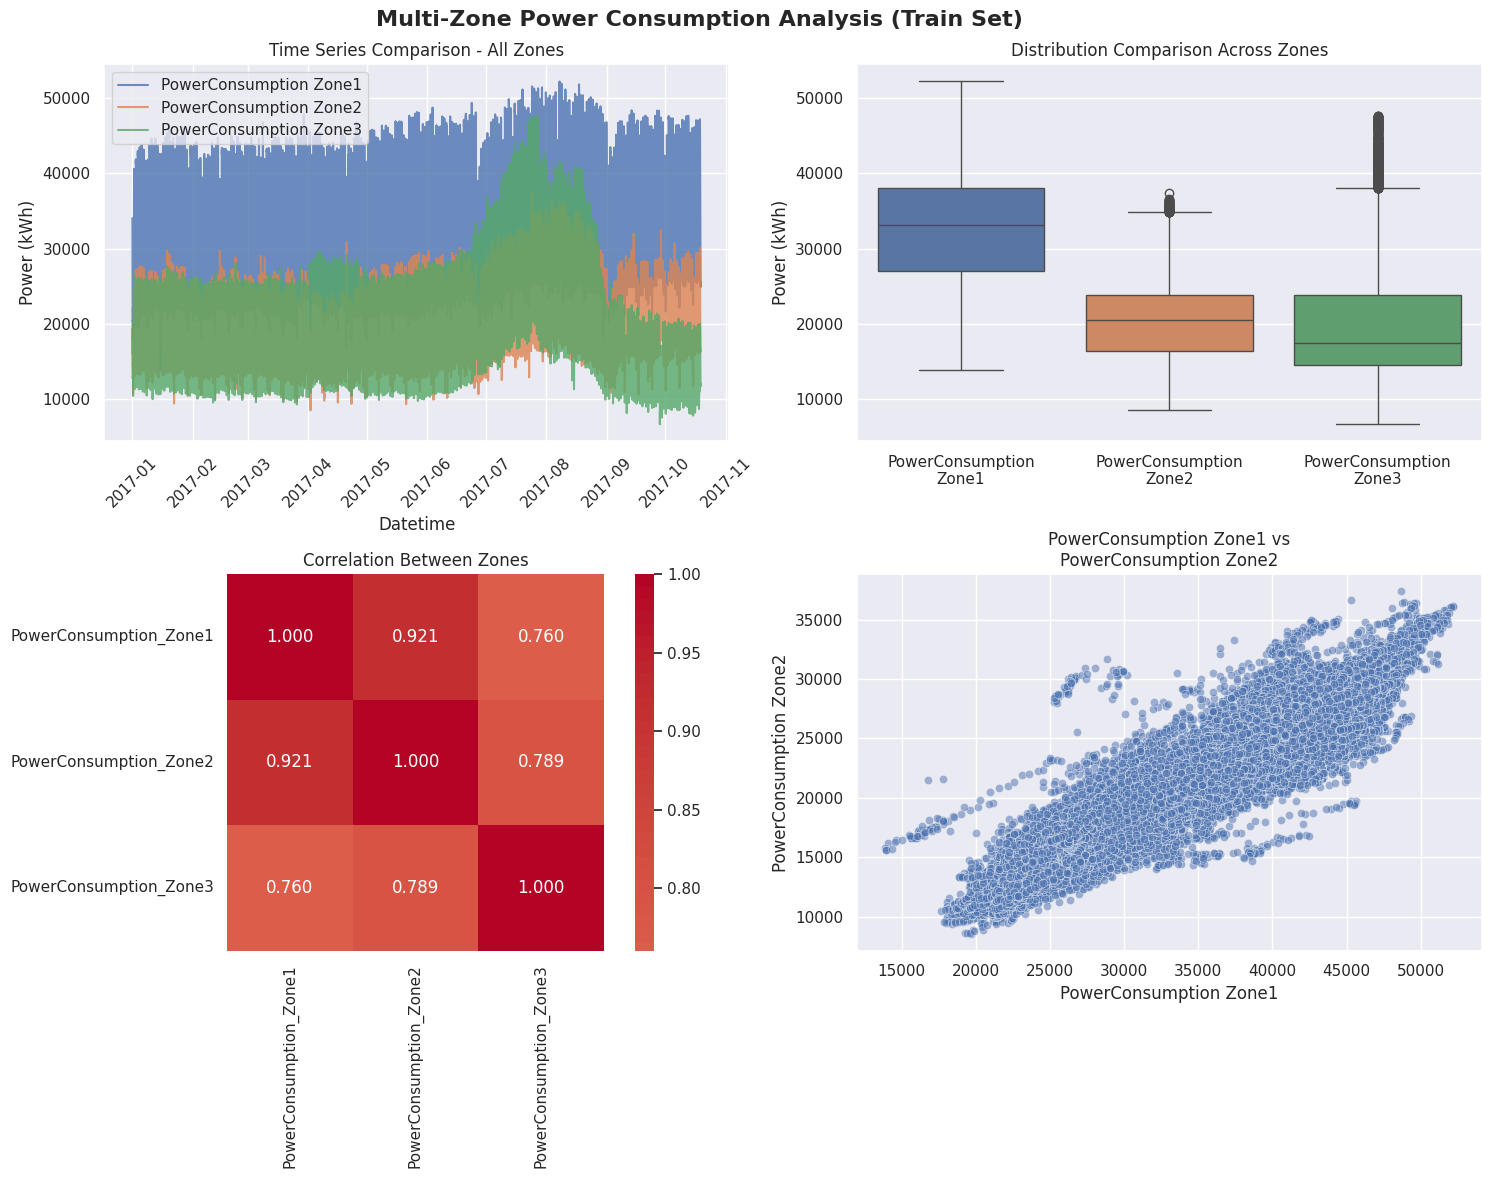

In [9]:
PowerConsumption_Zones = ['PowerConsumption_Zone1', 'PowerConsumption_Zone2', 'PowerConsumption_Zone3']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Multi-Zone Power Consumption Analysis (Train Set)', fontsize=16, fontweight='bold')

# 1. Time series comparison
for col in PowerConsumption_Zones:
    sns.lineplot(data=train_data, x='Datetime', y=col, ax=axes[0,0], label=col.replace('_', ' '), alpha=0.8)
axes[0,0].set_title('Time Series Comparison - All Zones')
axes[0,0].set_ylabel('Power (kWh)')
axes[0,0].tick_params(axis='x', rotation=45)
axes[0,0].legend()

# 2. Distribution comparison (boxplot)
sns.boxplot(data=train_data[PowerConsumption_Zones], ax=axes[0,1])
axes[0,1].set_xticklabels([col.replace('_', '\n') for col in PowerConsumption_Zones])
axes[0,1].set_title('Distribution Comparison Across Zones')
axes[0,1].set_ylabel('Power (kWh)')

# 3. Correlation heatmap
correlation_matrix = train_data[PowerConsumption_Zones].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, square=True, fmt='.3f', ax=axes[1,0])
axes[1,0].set_title('Correlation Between Zones')

# 4. Scatter plot matrix preview (Zone1 vs Zone2)
sns.scatterplot(data=train_data, x=PowerConsumption_Zones[0], y=PowerConsumption_Zones[1], ax=axes[1,1], alpha=0.5)
axes[1,1].set_title(f'{PowerConsumption_Zones[0].replace("_", " ")} vs\n{PowerConsumption_Zones[1].replace("_", " ")}')
axes[1,1].set_xlabel(PowerConsumption_Zones[0].replace('_', ' '))
axes[1,1].set_ylabel(PowerConsumption_Zones[1].replace('_', ' '))

#Stasts
print('\Average Consumption')
display(train_data['PowerConsumption_Zone3'].mean()) 


plt.tight_layout()
plt.show()

## Power Consumption Analysis

The power consumption analysis reveals a clear hierarchy and synchronized pattern across the three zones:

- **Zone 1** consistently demonstrates the highest energy demand, acting as the primary driver of total consumption.  
- The very strong correlation between **Zone 1** and **Zone 2** indicates their usage rises and falls in near-unison, suggesting they may be influenced by similar factors, such as commercial or industrial activity.  
- **Zone 3** follows the overall trend, but its lower and more stable consumption profile points to a potentially different type of load, such as a residential area with less variable demand.


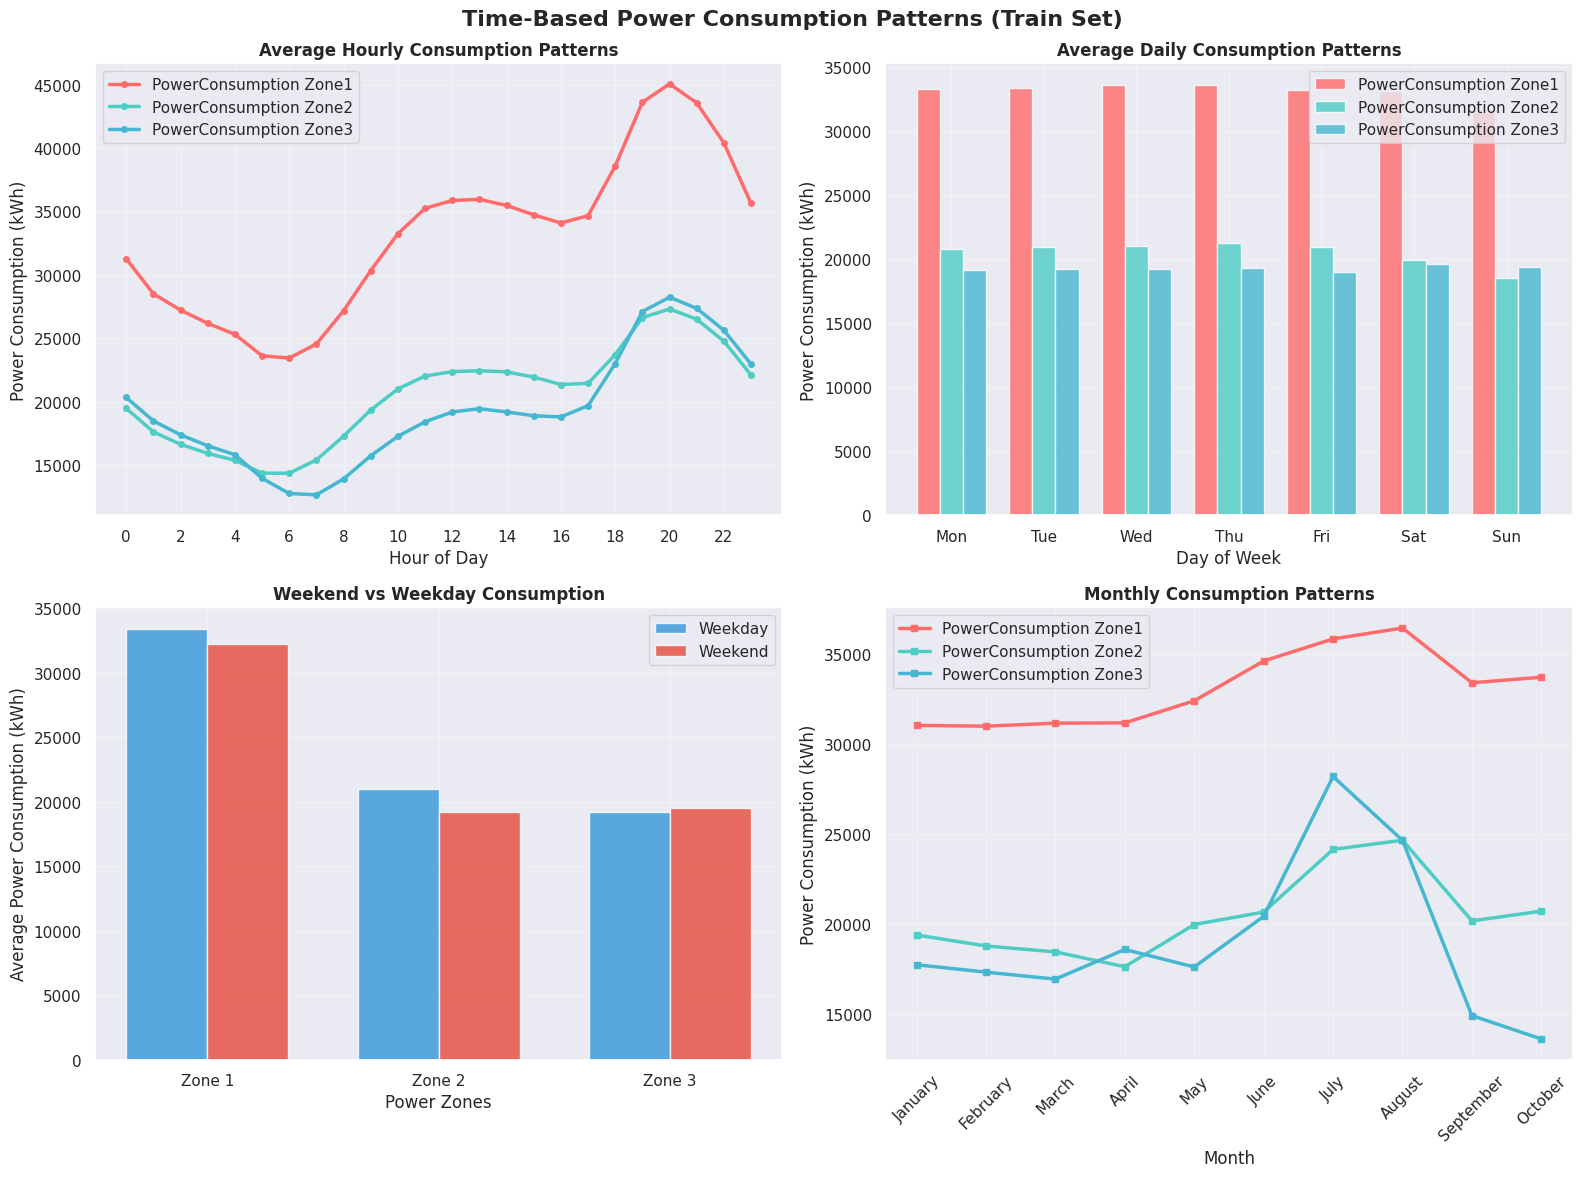

STATISTICAL ANALYSIS OF TIME-BASED PATTERNS (TRAIN SET)

3. SEASONAL ANALYSIS:
----------------------------------------
Seasonal Averages:
        PowerConsumption_Zone1  PowerConsumption_Zone2  PowerConsumption_Zone3
Season                                                                        
Winter                31010.31                19106.54                17551.00
Spring                31578.04                18701.21                17711.17
Summer                35635.17                23185.38                24468.06
Fall                  33512.91                20383.84                14432.46

4. PEAK HOUR ANALYSIS:
----------------------------------------
PowerConsumption_Zone1: Peak at 20:00 (45061.46 kWh), Lowest at 6:00 (23434.55 kWh)
PowerConsumption_Zone2: Peak at 20:00 (27304.89 kWh), Lowest at 6:00 (14345.28 kWh)
PowerConsumption_Zone3: Peak at 20:00 (28231.97 kWh), Lowest at 7:00 (12642.47 kWh)

5. TIME-BASED CORRELATION WITH HOUR:
--------------------------------

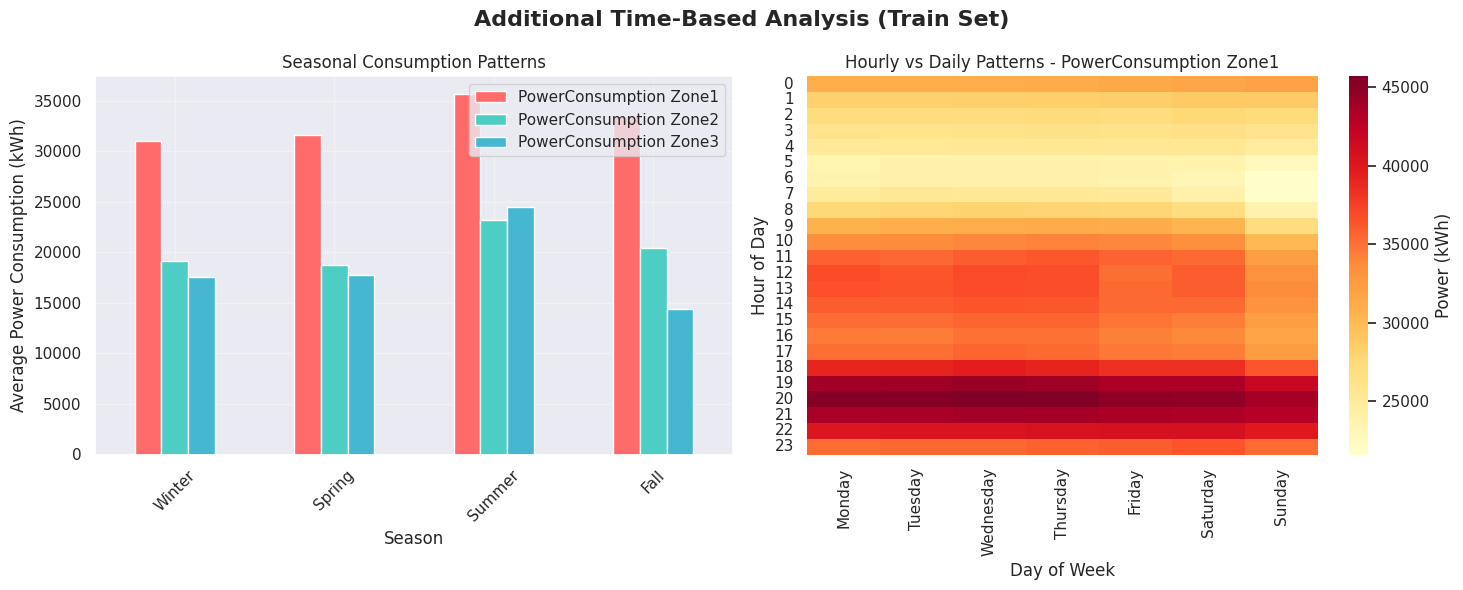


KEY INSIGHTS (TRAIN SET):
• Analyze peak consumption hours for load management
• Compare weekend vs weekday patterns for demand forecasting
• Identify seasonal trends for capacity planning
• Patterns learned from train set will inform model predictions


In [10]:
# Time-based analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Time-Based Power Consumption Patterns (Train Set)', fontsize=16, fontweight='bold')

# Define consistent colors for zones
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
zone_labels = [col.replace('_', ' ') for col in PowerConsumption_Zones]

# 1. Hourly patterns
hourly_avg = train_data.groupby('Hour')[PowerConsumption_Zones].mean()
for i, zone in enumerate(PowerConsumption_Zones):
    axes[0,0].plot(hourly_avg.index, hourly_avg[zone], label=zone_labels[i], 
                   color=colors[i], linewidth=2.5, marker='o', markersize=4)
axes[0,0].set_title('Average Hourly Consumption Patterns', fontweight='bold')
axes[0,0].set_ylabel('Power Consumption (kWh)')
axes[0,0].set_xlabel('Hour of Day')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)
axes[0,0].set_xticks(range(0, 24, 2))

# 2. Day of week patterns
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
# Map dayofweek numbers to day names
day_name_map = {0: 'Monday', 1: 'Tuesday', 2: 'Wednesday', 3: 'Thursday', 
                4: 'Friday', 5: 'Saturday', 6: 'Sunday'}
train_data['DayOfWeek_Name'] = train_data['DayOfWeek'].map(day_name_map)
daily_avg = train_data.groupby('DayOfWeek_Name')[PowerConsumption_Zones].mean().reindex(day_order)

x_pos = np.arange(len(day_order))
width = 0.25
for i, zone in enumerate(PowerConsumption_Zones):
    axes[0,1].bar(x_pos + i*width, daily_avg[zone], width, label=zone_labels[i], 
                  color=colors[i], alpha=0.8)
axes[0,1].set_title('Average Daily Consumption Patterns', fontweight='bold')
axes[0,1].set_xlabel('Day of Week')
axes[0,1].set_ylabel('Power Consumption (kWh)')
axes[0,1].set_xticks(x_pos + width)
axes[0,1].set_xticklabels([day[:3] for day in day_order])
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# 3. Weekend vs Weekday
train_data['Is_Weekend'] = train_data['DayOfWeek'] >= 5
weekend_avg = train_data.groupby('Is_Weekend')[PowerConsumption_Zones].mean()
weekend_labels = ['Weekday', 'Weekend']

x_pos = np.arange(len(PowerConsumption_Zones))
width = 0.35
for i, is_weekend in enumerate([False, True]):
    values = weekend_avg.loc[is_weekend].values
    axes[1,0].bar(x_pos + i*width, values, width, label=weekend_labels[i],
                  color=['#3498db', '#e74c3c'][i], alpha=0.8)

axes[1,0].set_title('Weekend vs Weekday Consumption', fontweight='bold')
axes[1,0].set_xlabel('Power Zones')
axes[1,0].set_ylabel('Average Power Consumption (kWh)')
axes[1,0].set_xticks(x_pos + width/2)
axes[1,0].set_xticklabels([f'Zone {i+1}' for i in range(len(PowerConsumption_Zones))])
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# 4. Monthly patterns
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']
month_name_map = {1: 'January', 2: 'February', 3: 'March', 4: 'April', 5: 'May', 6: 'June',
                  7: 'July', 8: 'August', 9: 'September', 10: 'October', 11: 'November', 12: 'December'}
train_data['Month_Name'] = train_data['Month'].map(month_name_map)
monthly_avg = train_data.groupby('Month_Name')[PowerConsumption_Zones].mean().reindex(month_order)

for i, zone in enumerate(PowerConsumption_Zones):
    axes[1,1].plot(monthly_avg.index, monthly_avg[zone], label=zone_labels[i],
                   color=colors[i], linewidth=2.5, marker='s', markersize=4)
axes[1,1].set_title('Monthly Consumption Patterns', fontweight='bold')
axes[1,1].set_xlabel('Month')
axes[1,1].set_ylabel('Power Consumption (kWh)')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# =============================================================================
# STATISTICAL ANALYSIS OF TIME PATTERNS (TRAIN SET)
# =============================================================================

print("="*70)
print("STATISTICAL ANALYSIS OF TIME-BASED PATTERNS (TRAIN SET)")
print("="*70)

# 1. Seasonal analysis
print("\n3. SEASONAL ANALYSIS:")
print("-" * 40)
train_data['Season'] = train_data['Month'].map({12: 'Winter', 1: 'Winter', 2: 'Winter',
                                          3: 'Spring', 4: 'Spring', 5: 'Spring',
                                          6: 'Summer', 7: 'Summer', 8: 'Summer',
                                          9: 'Fall', 10: 'Fall', 11: 'Fall'})
season_order = ['Winter', 'Spring', 'Summer', 'Fall']
seasonal_avg = train_data.groupby('Season')[PowerConsumption_Zones].mean().reindex(season_order)
print("Seasonal Averages:")
print(seasonal_avg.round(2))

# 2. Peak hour analysis
print("\n4. PEAK HOUR ANALYSIS:")
print("-" * 40)
for zone in PowerConsumption_Zones:
    peak_hour = hourly_avg[zone].idxmax()
    peak_value = hourly_avg[zone].max()
    off_peak_hour = hourly_avg[zone].idxmin()
    off_peak_value = hourly_avg[zone].min()
    print(f"{zone}: Peak at {peak_hour}:00 ({peak_value:.2f} kWh), "
          f"Lowest at {off_peak_hour}:00 ({off_peak_value:.2f} kWh)")

# 3. Time-based correlation analysis
print("\n5. TIME-BASED CORRELATION WITH HOUR:")
print("-" * 40)
for zone in PowerConsumption_Zones:
    correlation = train_data[zone].corr(train_data['Hour'])
    print(f"{zone}: Correlation with hour = {correlation:.4f}")

# 4. Daily pattern statistics
print("\n6. DAILY PATTERN STATISTICS:")
print("-" * 40)
daily_stats = train_data.groupby('DayOfWeek_Name')[PowerConsumption_Zones].agg(['mean', 'std']).reindex(day_order)
print(daily_stats.round(2))

# Additional visualization: Seasonal patterns
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Additional Time-Based Analysis (Train Set)', fontsize=16, fontweight='bold')

# Seasonal patterns
seasonal_avg.plot(kind='bar', ax=axes[0], color=colors)
axes[0].set_title('Seasonal Consumption Patterns')
axes[0].set_xlabel('Season')
axes[0].set_ylabel('Average Power Consumption (kWh)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(zone_labels)
axes[0].grid(True, alpha=0.3)

# Hourly distribution heatmap
hourly_pivot = train_data.pivot_table(values=PowerConsumption_Zones[0], 
                             index='Hour', columns='DayOfWeek_Name', 
                             aggfunc='mean').reindex(columns=day_order)
sns.heatmap(hourly_pivot, cmap='YlOrRd', ax=axes[1], cbar_kws={'label': 'Power (kWh)'})
axes[1].set_title(f'Hourly vs Daily Patterns - {zone_labels[0]}')
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Hour of Day')

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("KEY INSIGHTS (TRAIN SET):")
print("="*70)
print("• Analyze peak consumption hours for load management")
print("• Compare weekend vs weekday patterns for demand forecasting")
print("• Identify seasonal trends for capacity planning")
print("• Patterns learned from train set will inform model predictions")

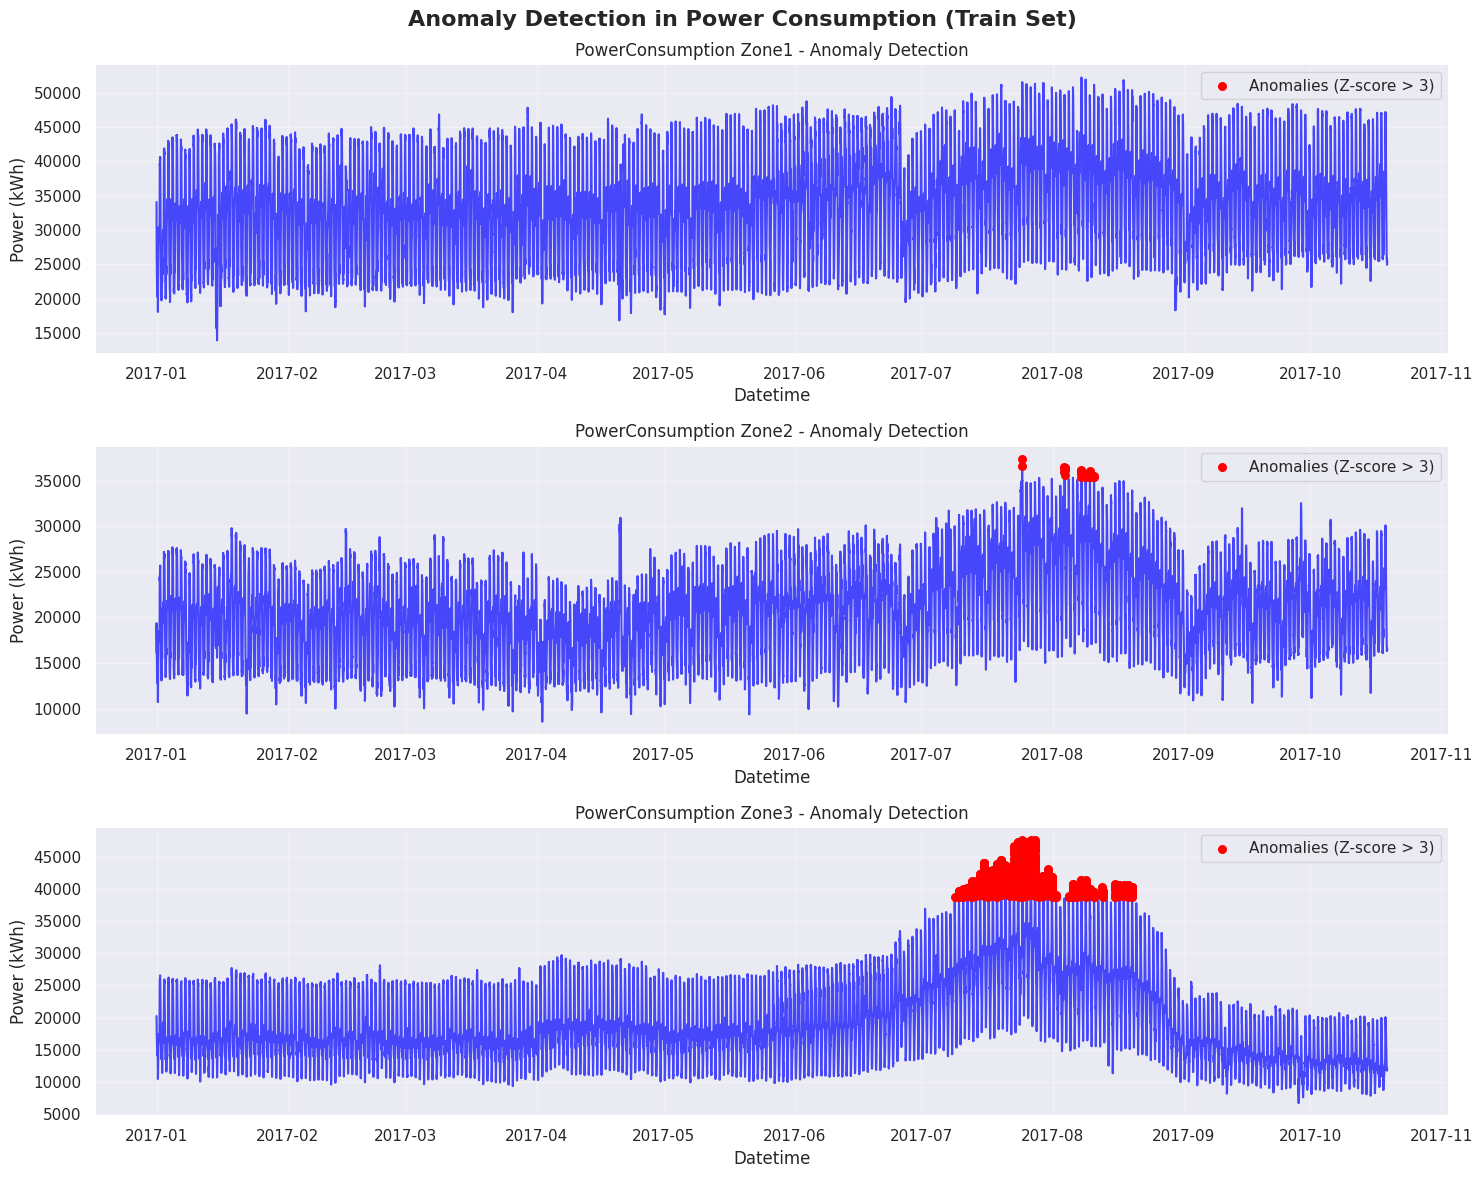

ANOMALY SUMMARY (TRAIN SET)
PowerConsumption Zone1: 0 anomalies (0.00%)
PowerConsumption Zone2: 30 anomalies (0.07%)
PowerConsumption Zone3: 532 anomalies (1.27%)


In [11]:
from scipy import stats

# Anomaly detection using Z-score
fig, axes = plt.subplots(3, 1, figsize=(15, 12))
fig.suptitle('Anomaly Detection in Power Consumption (Train Set)', fontsize=16, fontweight='bold')

for i, col in enumerate(PowerConsumption_Zones):
    ax = axes[i]
    
    # Calculate Z-scores
    z_scores = np.abs(stats.zscore(train_data[col]))
    anomalies = z_scores > 3
    
    # Plot with anomalies highlighted
    sns.lineplot(data=train_data, x='Datetime', y=col, ax=ax, alpha=0.7, color='blue')
    ax.scatter(train_data[anomalies]['Datetime'], train_data[anomalies][col], 
              color='red', s=30, label='Anomalies (Z-score > 3)', zorder=5)
    
    ax.set_title(f'{col.replace("_", " ")} - Anomaly Detection')
    ax.set_ylabel('Power (kWh)')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print anomaly summary
print("="*50)
print("ANOMALY SUMMARY (TRAIN SET)")
print("="*50)
for col in PowerConsumption_Zones:
    z_scores = np.abs(stats.zscore(train_data[col]))
    anomaly_count = (z_scores > 3).sum()
    print(f"{col.replace('_', ' ')}: {anomaly_count} anomalies ({anomaly_count/len(train_data)*100:.2f}%)")

In [12]:
# Calculate additional metrics
print("Energy Consumption Metrics (Train Set)")
print("="*50)

for col in PowerConsumption_Zones:
    total_energy = train_data[col].sum()
    avg_daily = train_data.groupby(train_data['Datetime'].dt.date)[col].sum().mean()
    peak_demand = train_data[col].max()
    load_factor = train_data[col].mean() / peak_demand * 100
    
    print(f"\n{col.replace('_', ' ')}:")
    print(f"  Total Energy: {total_energy:,.0f} kWh")
    print(f"  Average Daily: {avg_daily:,.1f} kWh")
    print(f"  Peak Demand: {peak_demand:.1f} kWh")
    print(f"  Load Factor: {load_factor:.1f}%")

# Additional comparative metrics
print("\n" + "="*50)
print("Comparative Metrics (Train Set)")
print("="*50)

# Calculate percentage distribution across zones
total_energy_all_zones = sum(train_data[col].sum() for col in PowerConsumption_Zones)
print(f"\nTotal Energy Across All Zones: {total_energy_all_zones:,.0f} kWh")

for col in PowerConsumption_Zones:
    zone_energy = train_data[col].sum()
    percentage = (zone_energy / total_energy_all_zones) * 100
    print(f"{col.replace('_', ' ')}: {percentage:.1f}% of total energy")

# Calculate variability metrics
print("\nVariability Metrics:")
print("-" * 30)
for col in PowerConsumption_Zones:
    cv = (train_data[col].std() / train_data[col].mean()) * 100  # Coefficient of variation
    daily_range = train_data.groupby(train_data['Datetime'].dt.date)[col].max() - train_data.groupby(train_data['Datetime'].dt.date)[col].min()
    avg_daily_range = daily_range.mean()
    
    print(f"\n{col.replace('_', ' ')}:")
    print(f"  Coefficient of Variation: {cv:.1f}%")
    print(f"  Average Daily Range: {avg_daily_range:.1f} kWh")

Energy Consumption Metrics (Train Set)

PowerConsumption Zone1:
  Total Energy: 1,386,483,704 kWh
  Average Daily: 4,748,231.9 kWh
  Peak Demand: 52204.4 kWh
  Load Factor: 63.3%

PowerConsumption Zone2:
  Total Energy: 858,706,512 kWh
  Average Daily: 2,940,775.7 kWh
  Peak Demand: 37408.9 kWh
  Load Factor: 54.7%

PowerConsumption Zone3:
  Total Energy: 808,064,974 kWh
  Average Daily: 2,767,345.8 kWh
  Peak Demand: 47598.3 kWh
  Load Factor: 40.5%

Comparative Metrics (Train Set)

Total Energy Across All Zones: 3,053,255,191 kWh
PowerConsumption Zone1: 45.4% of total energy
PowerConsumption Zone2: 28.1% of total energy
PowerConsumption Zone3: 26.5% of total energy

Variability Metrics:
------------------------------

PowerConsumption Zone1:
  Coefficient of Variation: 21.7%
  Average Daily Range: 23645.0 kWh

PowerConsumption Zone2:
  Coefficient of Variation: 24.3%
  Average Daily Range: 14536.3 kWh

PowerConsumption Zone3:
  Coefficient of Variation: 33.5%
  Average Daily Range: 1

## Zone 1 Load Characteristics

- **Dominant Demand:** Zone 1 dominates system demand, accounting for nearly half (**45.4%**) of the total energy consumption.  
- **Peak and Efficiency:** Despite having the highest peak demand, it maintains the best load factor (**63.3%**), indicating more stable and efficient energy utilization compared to other zones.  
- **Variability:** Its moderate variability further confirms its role as the system's backbone load.


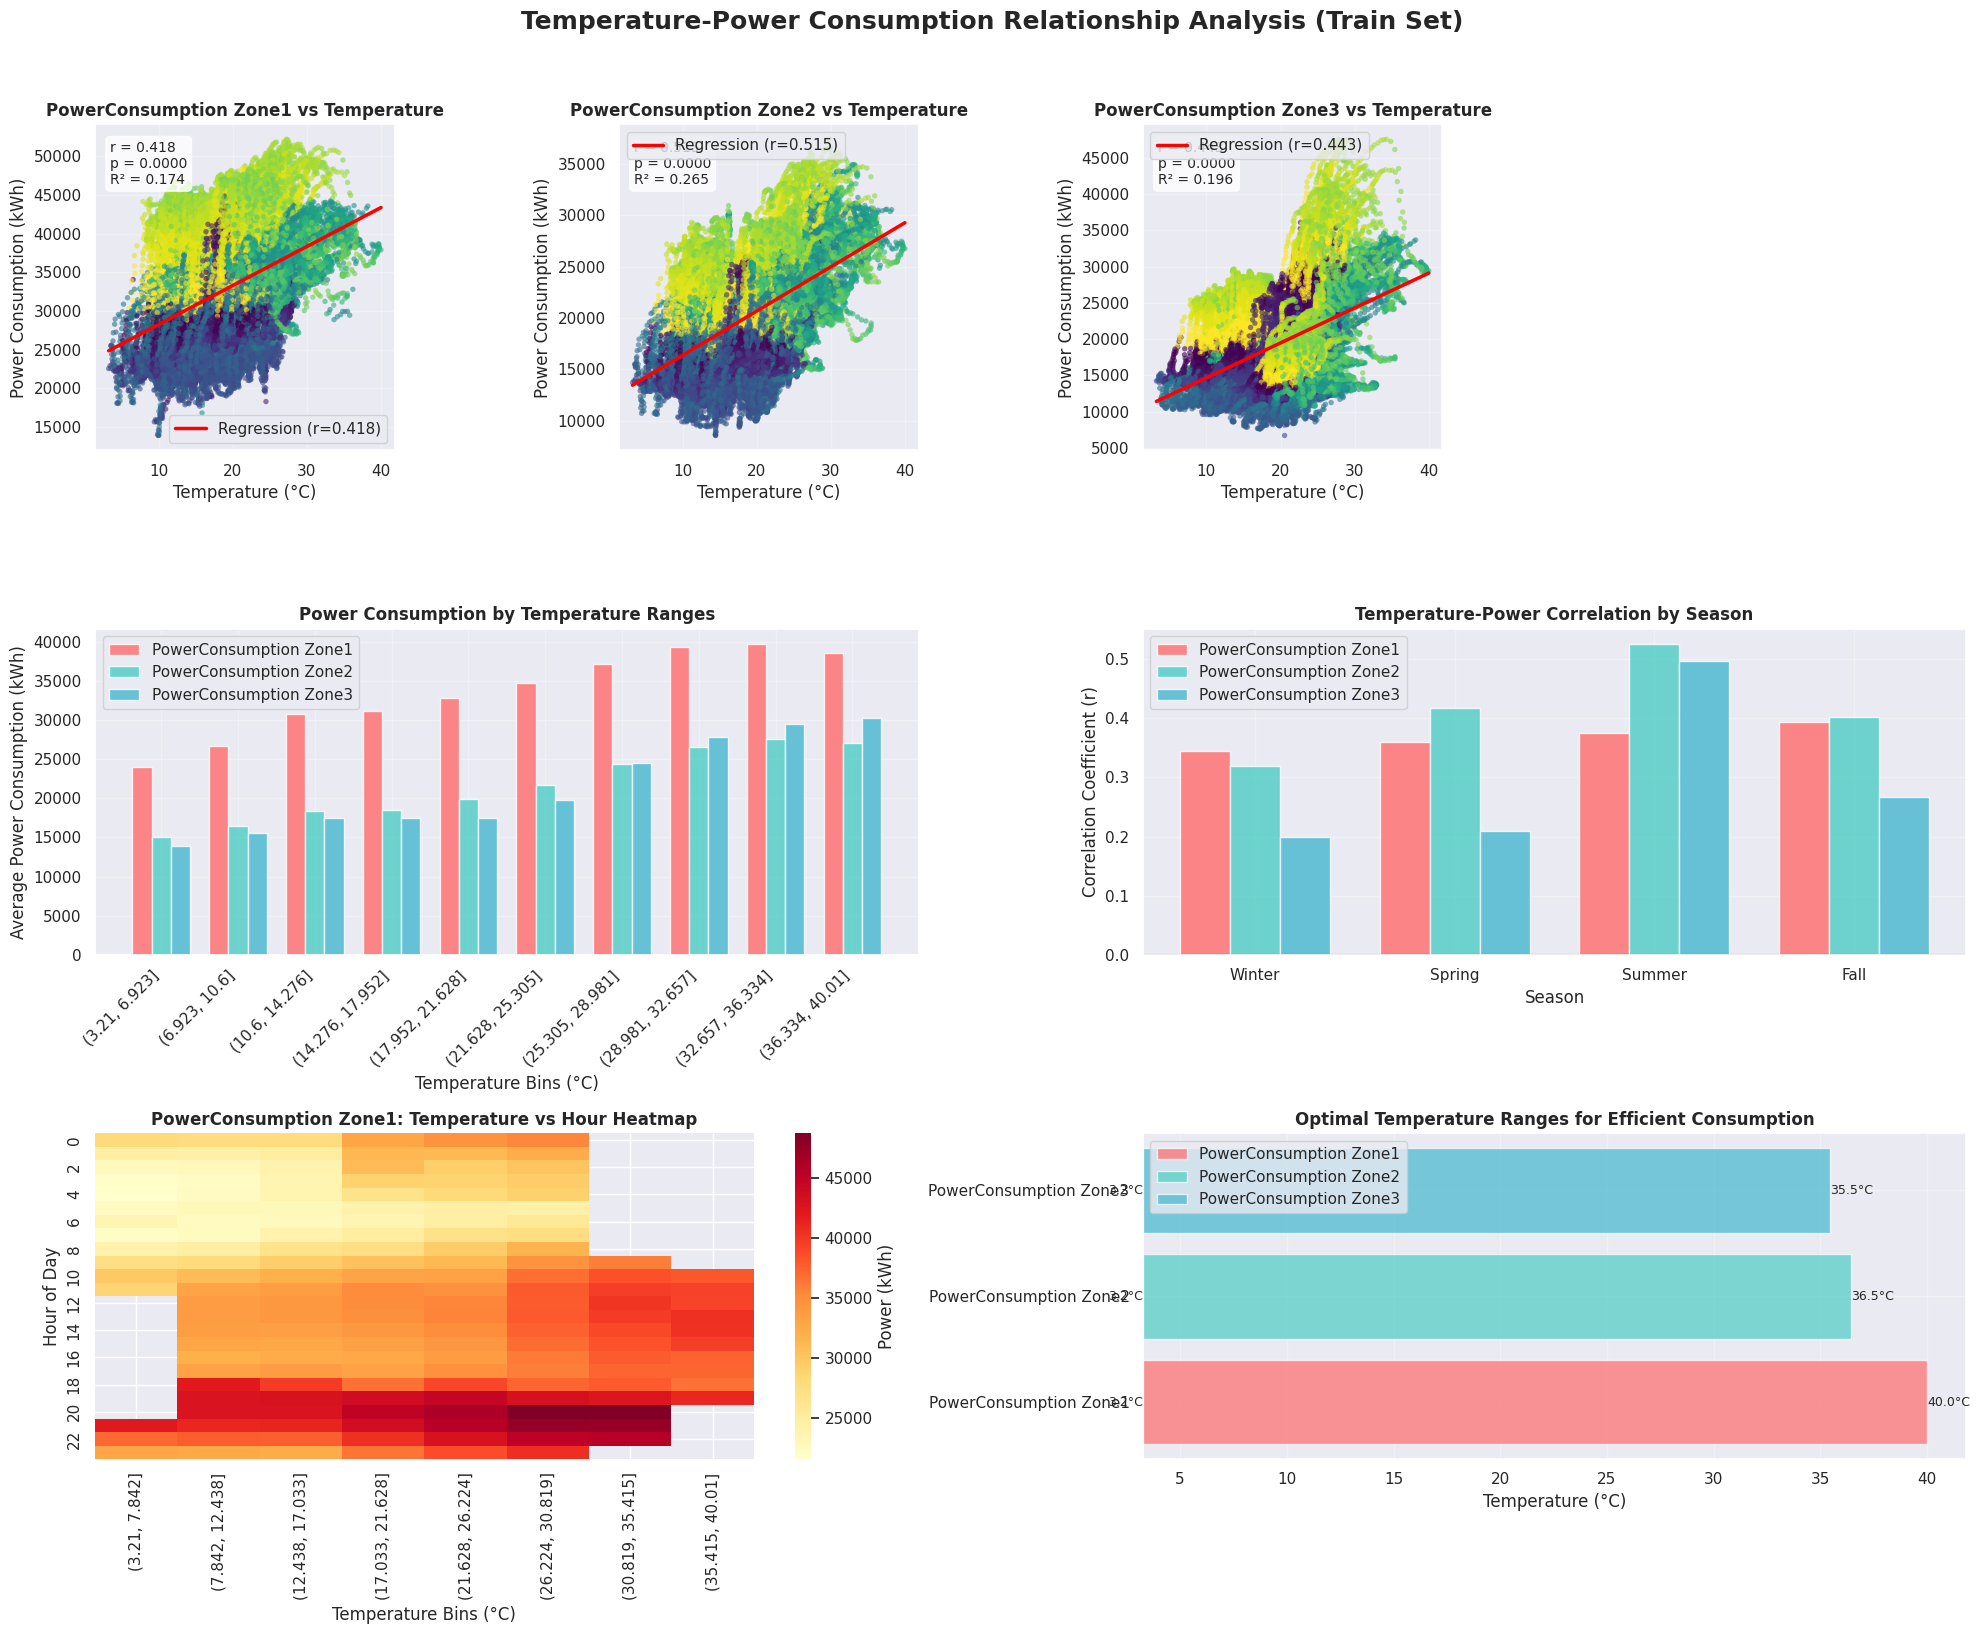

TEMPERATURE-POWER CONSUMPTION STATISTICAL SUMMARY

PowerConsumption Zone1:
  Correlation (r): 0.4177
  R-squared: 0.1745
  p-value: 0.0000
  Regression: Power = 503.796×Temp + 23210.756
  Most Efficient Temp: 10.0°C
  Peak Consumption Temp: 27.2°C

PowerConsumption Zone2:
  Correlation (r): 0.5149
  R-squared: 0.2651
  p-value: 0.0000
  Regression: Power = 430.352×Temp + 12060.812
  Most Efficient Temp: 14.5°C
  Peak Consumption Temp: 29.8°C

PowerConsumption Zone3:
  Correlation (r): 0.4432
  R-squared: 0.1964
  p-value: 0.0000
  Regression: Power = 481.740×Temp + 9847.963
  Most Efficient Temp: 20.6°C
  Peak Consumption Temp: 29.1°C

TEMPERATURE SENSITIVITY COMPARISON
                  Zone  Sensitivity (kWh/°C)  Relative Sensitivity
PowerConsumption Zone1                503.80                  1.00
PowerConsumption Zone2                430.35                  0.85
PowerConsumption Zone3                481.74                  0.96


In [13]:
from matplotlib import gridspec

# Advanced Temperature-Power Consumption Analysis
fig = plt.figure(figsize=(20, 16))
fig.suptitle('Temperature-Power Consumption Relationship Analysis (Train Set)', 
             fontsize=18, y=1.02, fontweight='bold')

# Create custom grid layout
gs = gridspec.GridSpec(3, 4, figure=fig)

# Define palette for zones
palette = ['#FF6B6B', '#4ECDC4', '#45B7D1']

# 1. Scatter plots with enhanced regression analysis
for i, col in enumerate(PowerConsumption_Zones):
    ax = fig.add_subplot(gs[0, i])
    
    # Calculate correlation and regression
    corr = train_data[['Temperature', col]].corr().iloc[0,1]
    slope, intercept, r_value, p_value, std_err = stats.linregress(train_data['Temperature'], train_data[col])
    
    # Enhanced scatter plot with density coloring
    scatter = ax.scatter(train_data['Temperature'], train_data[col], 
                        c=train_data['Hour'], cmap='viridis', alpha=0.6, 
                        s=15, edgecolors='none')
    
    # Add regression line with confidence interval
    x_range = np.linspace(train_data['Temperature'].min(), train_data['Temperature'].max(), 100)
    y_pred = slope * x_range + intercept
    
    # Calculate confidence interval
    y_err = std_err * np.sqrt(1/len(train_data) + (x_range - train_data['Temperature'].mean())**2 / np.sum((train_data['Temperature'] - train_data['Temperature'].mean())**2))
    ax.fill_between(x_range, y_pred - 1.96*y_err, y_pred + 1.96*y_err, alpha=0.2, color=palette[i])
    ax.plot(x_range, y_pred, color='red', linewidth=2.5, label=f'Regression (r={corr:.3f})')
    
    # Add statistical annotations
    ax.text(0.05, 0.95, f'r = {corr:.3f}\np = {p_value:.4f}\nR² = {r_value**2:.3f}', 
            transform=ax.transAxes, fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    ax.set_title(f'{col.replace("_", " ")} vs Temperature', fontweight='bold')
    ax.set_xlabel('Temperature (°C)')
    ax.set_ylabel('Power Consumption (kWh)')
    ax.grid(True, alpha=0.3)
    ax.legend()

# 2. Temperature bins analysis
ax_bins = fig.add_subplot(gs[1, :2])
temp_bins = pd.cut(train_data['Temperature'], bins=10)
bin_analysis = train_data.groupby(temp_bins)[PowerConsumption_Zones].mean()

width = 0.25
x_pos = np.arange(len(bin_analysis))
for i, col in enumerate(PowerConsumption_Zones):
    ax_bins.bar(x_pos + i*width, bin_analysis[col], width, 
                label=col.replace('_', ' '), color=palette[i], alpha=0.8)

ax_bins.set_xlabel('Temperature Bins (°C)')
ax_bins.set_ylabel('Average Power Consumption (kWh)')
ax_bins.set_title('Power Consumption by Temperature Ranges', fontweight='bold')
ax_bins.set_xticks(x_pos + width)
ax_bins.set_xticklabels([str(bin) for bin in bin_analysis.index], rotation=45, ha='right')
ax_bins.legend()
ax_bins.grid(True, alpha=0.3)

# 3. Seasonal temperature relationship
ax_seasonal = fig.add_subplot(gs[1, 2:])
seasonal_corr = []
seasons = ['Winter', 'Spring', 'Summer', 'Fall']

for season in seasons:
    season_data = train_data[train_data['Season'] == season]
    corrs = [season_data[['Temperature', col]].corr().iloc[0,1] for col in PowerConsumption_Zones]
    seasonal_corr.append(corrs)

seasonal_corr_df = pd.DataFrame(seasonal_corr, index=seasons, 
                               columns=[col.replace('_', ' ') for col in PowerConsumption_Zones])

x_pos_season = np.arange(len(seasons))
width = 0.25
for i, col in enumerate(seasonal_corr_df.columns):
    ax_seasonal.bar(x_pos_season + i*width, seasonal_corr_df[col], width,
                   label=col, color=palette[i], alpha=0.8)

ax_seasonal.set_xlabel('Season')
ax_seasonal.set_ylabel('Correlation Coefficient (r)')
ax_seasonal.set_title('Temperature-Power Correlation by Season', fontweight='bold')
ax_seasonal.set_xticks(x_pos_season + width)
ax_seasonal.set_xticklabels(seasons)
ax_seasonal.legend()
ax_seasonal.grid(True, alpha=0.3)
ax_seasonal.axhline(y=0, color='black', linestyle='-', alpha=0.5)

# 4. Heatmap: Temperature vs Hour vs Power Consumption
ax_heatmap = fig.add_subplot(gs[2, :2])
heatmap_data = train_data.pivot_table(values=PowerConsumption_Zones[0], 
                                     index='Hour', 
                                     columns=pd.cut(train_data['Temperature'], bins=8),
                                     aggfunc='mean')

sns.heatmap(heatmap_data, cmap='YlOrRd', ax=ax_heatmap, cbar_kws={'label': 'Power (kWh)'})
ax_heatmap.set_title(f'{PowerConsumption_Zones[0].replace("_", " ")}: Temperature vs Hour Heatmap', 
                    fontweight='bold')
ax_heatmap.set_xlabel('Temperature Bins (°C)')
ax_heatmap.set_ylabel('Hour of Day')

# 5. Optimal temperature ranges
ax_optimal = fig.add_subplot(gs[2, 2:])
optimal_ranges = []

for i, col in enumerate(PowerConsumption_Zones):
    # Find temperature range where consumption is below 75th percentile (efficient range)
    efficient_data = train_data[train_data[col] <= train_data[col].quantile(0.75)]
    temp_range = (efficient_data['Temperature'].min(), efficient_data['Temperature'].max())
    optimal_ranges.append(temp_range)
    
    ax_optimal.barh(i, temp_range[1]-temp_range[0], left=temp_range[0], 
                   color=palette[i], alpha=0.7, label=col.replace('_', ' '))
    ax_optimal.text(temp_range[0], i, f'{temp_range[0]:.1f}°C', 
                   va='center', ha='right', fontsize=9)
    ax_optimal.text(temp_range[1], i, f'{temp_range[1]:.1f}°C', 
                   va='center', ha='left', fontsize=9)

ax_optimal.set_yticks(range(len(PowerConsumption_Zones)))
ax_optimal.set_yticklabels([col.replace('_', ' ') for col in PowerConsumption_Zones])
ax_optimal.set_xlabel('Temperature (°C)')
ax_optimal.set_title('Optimal Temperature Ranges for Efficient Consumption', fontweight='bold')
ax_optimal.legend()
ax_optimal.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Statistical summary
print("="*70)
print("TEMPERATURE-POWER CONSUMPTION STATISTICAL SUMMARY")
print("="*70)

for col in PowerConsumption_Zones:
    corr = train_data[['Temperature', col]].corr().iloc[0,1]
    slope, intercept, r_value, p_value, std_err = stats.linregress(train_data['Temperature'], train_data[col])
    
    print(f"\n{col.replace('_', ' ')}:")
    print(f"  Correlation (r): {corr:.4f}")
    print(f"  R-squared: {r_value**2:.4f}")
    print(f"  p-value: {p_value:.4f}")
    print(f"  Regression: Power = {slope:.3f}×Temp + {intercept:.3f}")
    
    # Optimal temperature analysis
    optimal_temp = train_data.loc[train_data[col].idxmin(), 'Temperature']
    peak_temp = train_data.loc[train_data[col].idxmax(), 'Temperature']
    print(f"  Most Efficient Temp: {optimal_temp:.1f}°C")
    print(f"  Peak Consumption Temp: {peak_temp:.1f}°C")

# Cross-zone temperature sensitivity comparison
print("\n" + "="*70)
print("TEMPERATURE SENSITIVITY COMPARISON")
print("="*70)

sensitivities = []
for col in PowerConsumption_Zones:
    slope, _, _, _, _ = stats.linregress(train_data['Temperature'], train_data[col])
    sensitivities.append(slope)

sensitivity_df = pd.DataFrame({
    'Zone': [col.replace('_', ' ') for col in PowerConsumption_Zones],
    'Sensitivity (kWh/°C)': sensitivities,
    'Relative Sensitivity': [s/max(sensitivities) for s in sensitivities]
})

print(sensitivity_df.to_string(index=False))

##  Conclusion

The analysis of power consumption across Tetouan's three zones reveals a clear hierarchy and distinct operational profiles, with climate playing a key role in demand volatility.

### Zone 1: The Primary Load Center
- **Share of Consumption:** 45.4% of all energy consumed.  
- **Load Factor:** 63.3%, indicating stable and efficient utilization despite the highest peak demand.  
- **Role:** Serves as the system's backbone load.



### Key Insight
The disparity in Load Factor—from 63.3% in Zone 1 down to 40.5% in Zone 3—highlights a major opportunity for demand-side management. Implementing strategies to flatten the peaky demand in Zone 3 could significantly enhance the overall efficiency and reliability of the city's power grid.


##  Recommended Energy-Saving Strategies – Summary

1. **Targeted Peak Shaving in Zone 3**  
   - **Action:** Use demand response programs and smart thermostats.  
   - **Reason:** Zone 3 has the lowest Load Factor (40.5%) and highest volatility; reducing peaks improves grid stability.

2. **Load Balancing & Efficiency Incentives**  
   - **Action:** Shift flexible load from Zone 3 to off-peak periods in Zone 1.  
   - **Reason:** Zone 1's high Load Factor (63.3%) makes it efficient for base-load management, helping balance Zone 3.

3. **Predictive Climate-Control for Zones 2 & 3**  
   - **Action:** Deploy AI-driven HVAC systems to pre-cool buildings based on forecasts.  
   - **Reason:** Prevents reactive high-power consumption during summer peaks.

4. **Strategic Solar Integration for Peak Demand**  
   - **Action:** Install solar power and storage for Zone 3's daytime peaks.  
   - **Reason:** Solar output aligns with afternoon cooling loads, offsetting inefficient grid usage.

5. **Mandatory Efficiency Upgrades in Zone 3**  
   - **Action:** Enforce energy audits and retrofits (insulation, efficient cooling).  
   - **Reason:** Poor load factor reflects building inefficiencies; technology alone isn’t enough for long-term savings.


In [14]:
#selecting numeric columns
numeric_columns = train_data.select_dtypes(include=['number'])


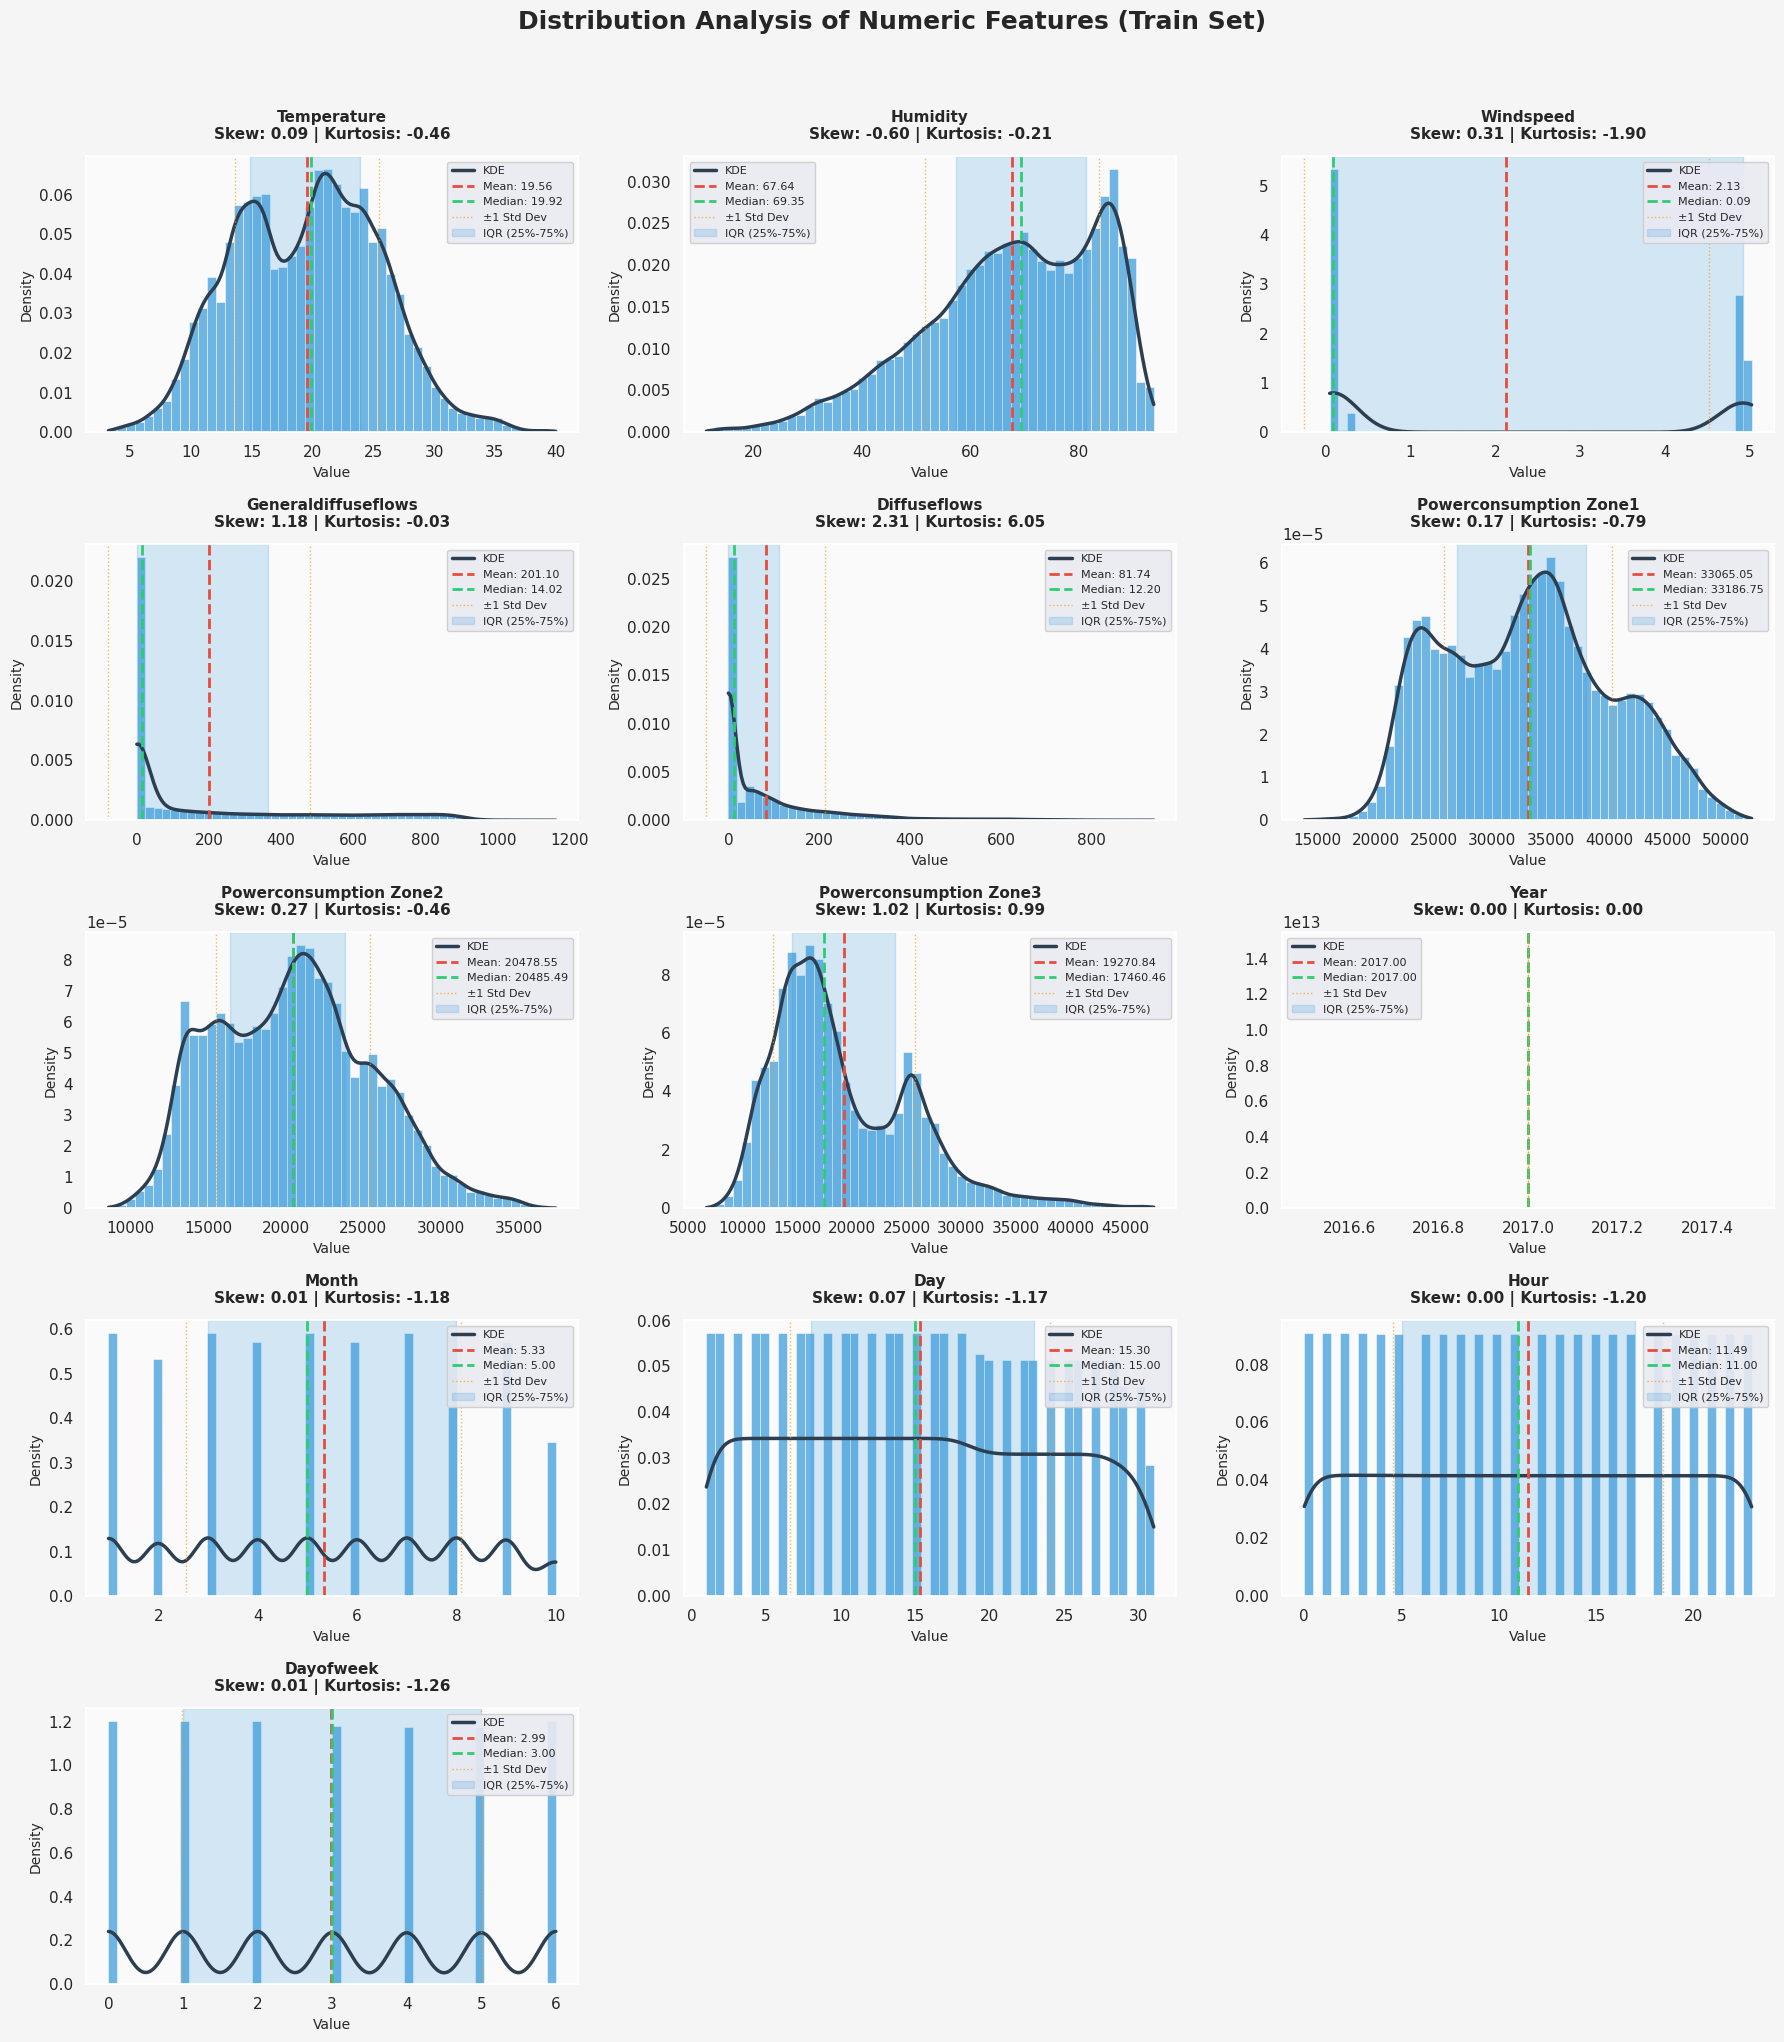

In [15]:
#Distribution Analysis with Statistical Insights
import math

num_cols = len(numeric_columns.columns)
n_rows = math.ceil(num_cols / 3)
n_cols = min(3, num_cols)

plt.figure(figsize=(6 * n_cols, 4 * n_rows), facecolor='#f5f5f5')
plt.suptitle('Distribution Analysis of Numeric Features (Train Set)', 
             y=1.02, fontsize=18, fontweight='bold')

# Use a single color for all plots
primary_color = '#3498db'  # Blue color
secondary_color = '#2c3e50'  # Dark blue for KDE
accent_colors = ['#e74c3c', '#2ecc71', '#f39c12']  # For mean, median, std dev

for i, col in enumerate(numeric_columns.columns, 1):
    plt.subplot(n_rows, n_cols, i)
    
    # Calculate statistical measures
    data = numeric_columns[col]
    mean_val = data.mean()
    median_val = data.median()
    std_val = data.std()
    skew_val = data.skew()
    kurtosis_val = data.kurtosis()
    
    # Create enhanced histogram with consistent color
    n, bins, patches = plt.hist(data, bins=50, alpha=0.7, color=primary_color, 
                               edgecolor='white', linewidth=0.5, density=True)
    
    # Overlay KDE with consistent color
    kde = stats.gaussian_kde(data)
    x_range = np.linspace(data.min(), data.max(), 200)
    kde_vals = kde(x_range)
    plt.plot(x_range, kde_vals, color=secondary_color, linewidth=2.5, label='KDE')
    
    # Add statistical lines with consistent accent colors
    plt.axvline(mean_val, color=accent_colors[0], linestyle='--', linewidth=2, 
                label=f'Mean: {mean_val:.2f}')
    plt.axvline(median_val, color=accent_colors[1], linestyle='--', linewidth=2,
                label=f'Median: {median_val:.2f}')
    plt.axvline(mean_val + std_val, color=accent_colors[2], linestyle=':', linewidth=1,
                alpha=0.7, label='±1 Std Dev')
    plt.axvline(mean_val - std_val, color=accent_colors[2], linestyle=':', linewidth=1, alpha=0.7)
    
    # Add quartile regions with consistent color
    q25, q75 = np.percentile(data, [25, 75])
    plt.axvspan(q25, q75, alpha=0.2, color=primary_color, label='IQR (25%-75%)')
    
    # Customize title with statistical metrics
    plt.title(f'{col.replace("_", " ").title()}\n'
              f'Skew: {skew_val:.2f} | Kurtosis: {kurtosis_val:.2f}', 
              pad=12, fontsize=11, fontweight='bold')
    
    plt.xlabel('Value', fontsize=10)
    plt.ylabel('Density', fontsize=10)
    
    # Enhanced grid and styling
    plt.grid(True, alpha=0.2, linestyle='--')
    plt.gca().set_facecolor('#fafafa')
    
    # Add legend with statistical summary
    plt.legend(frameon=True, framealpha=0.9, fontsize=8, 
              loc='upper right' if skew_val > 0 else 'upper left')

plt.tight_layout()
plt.show()

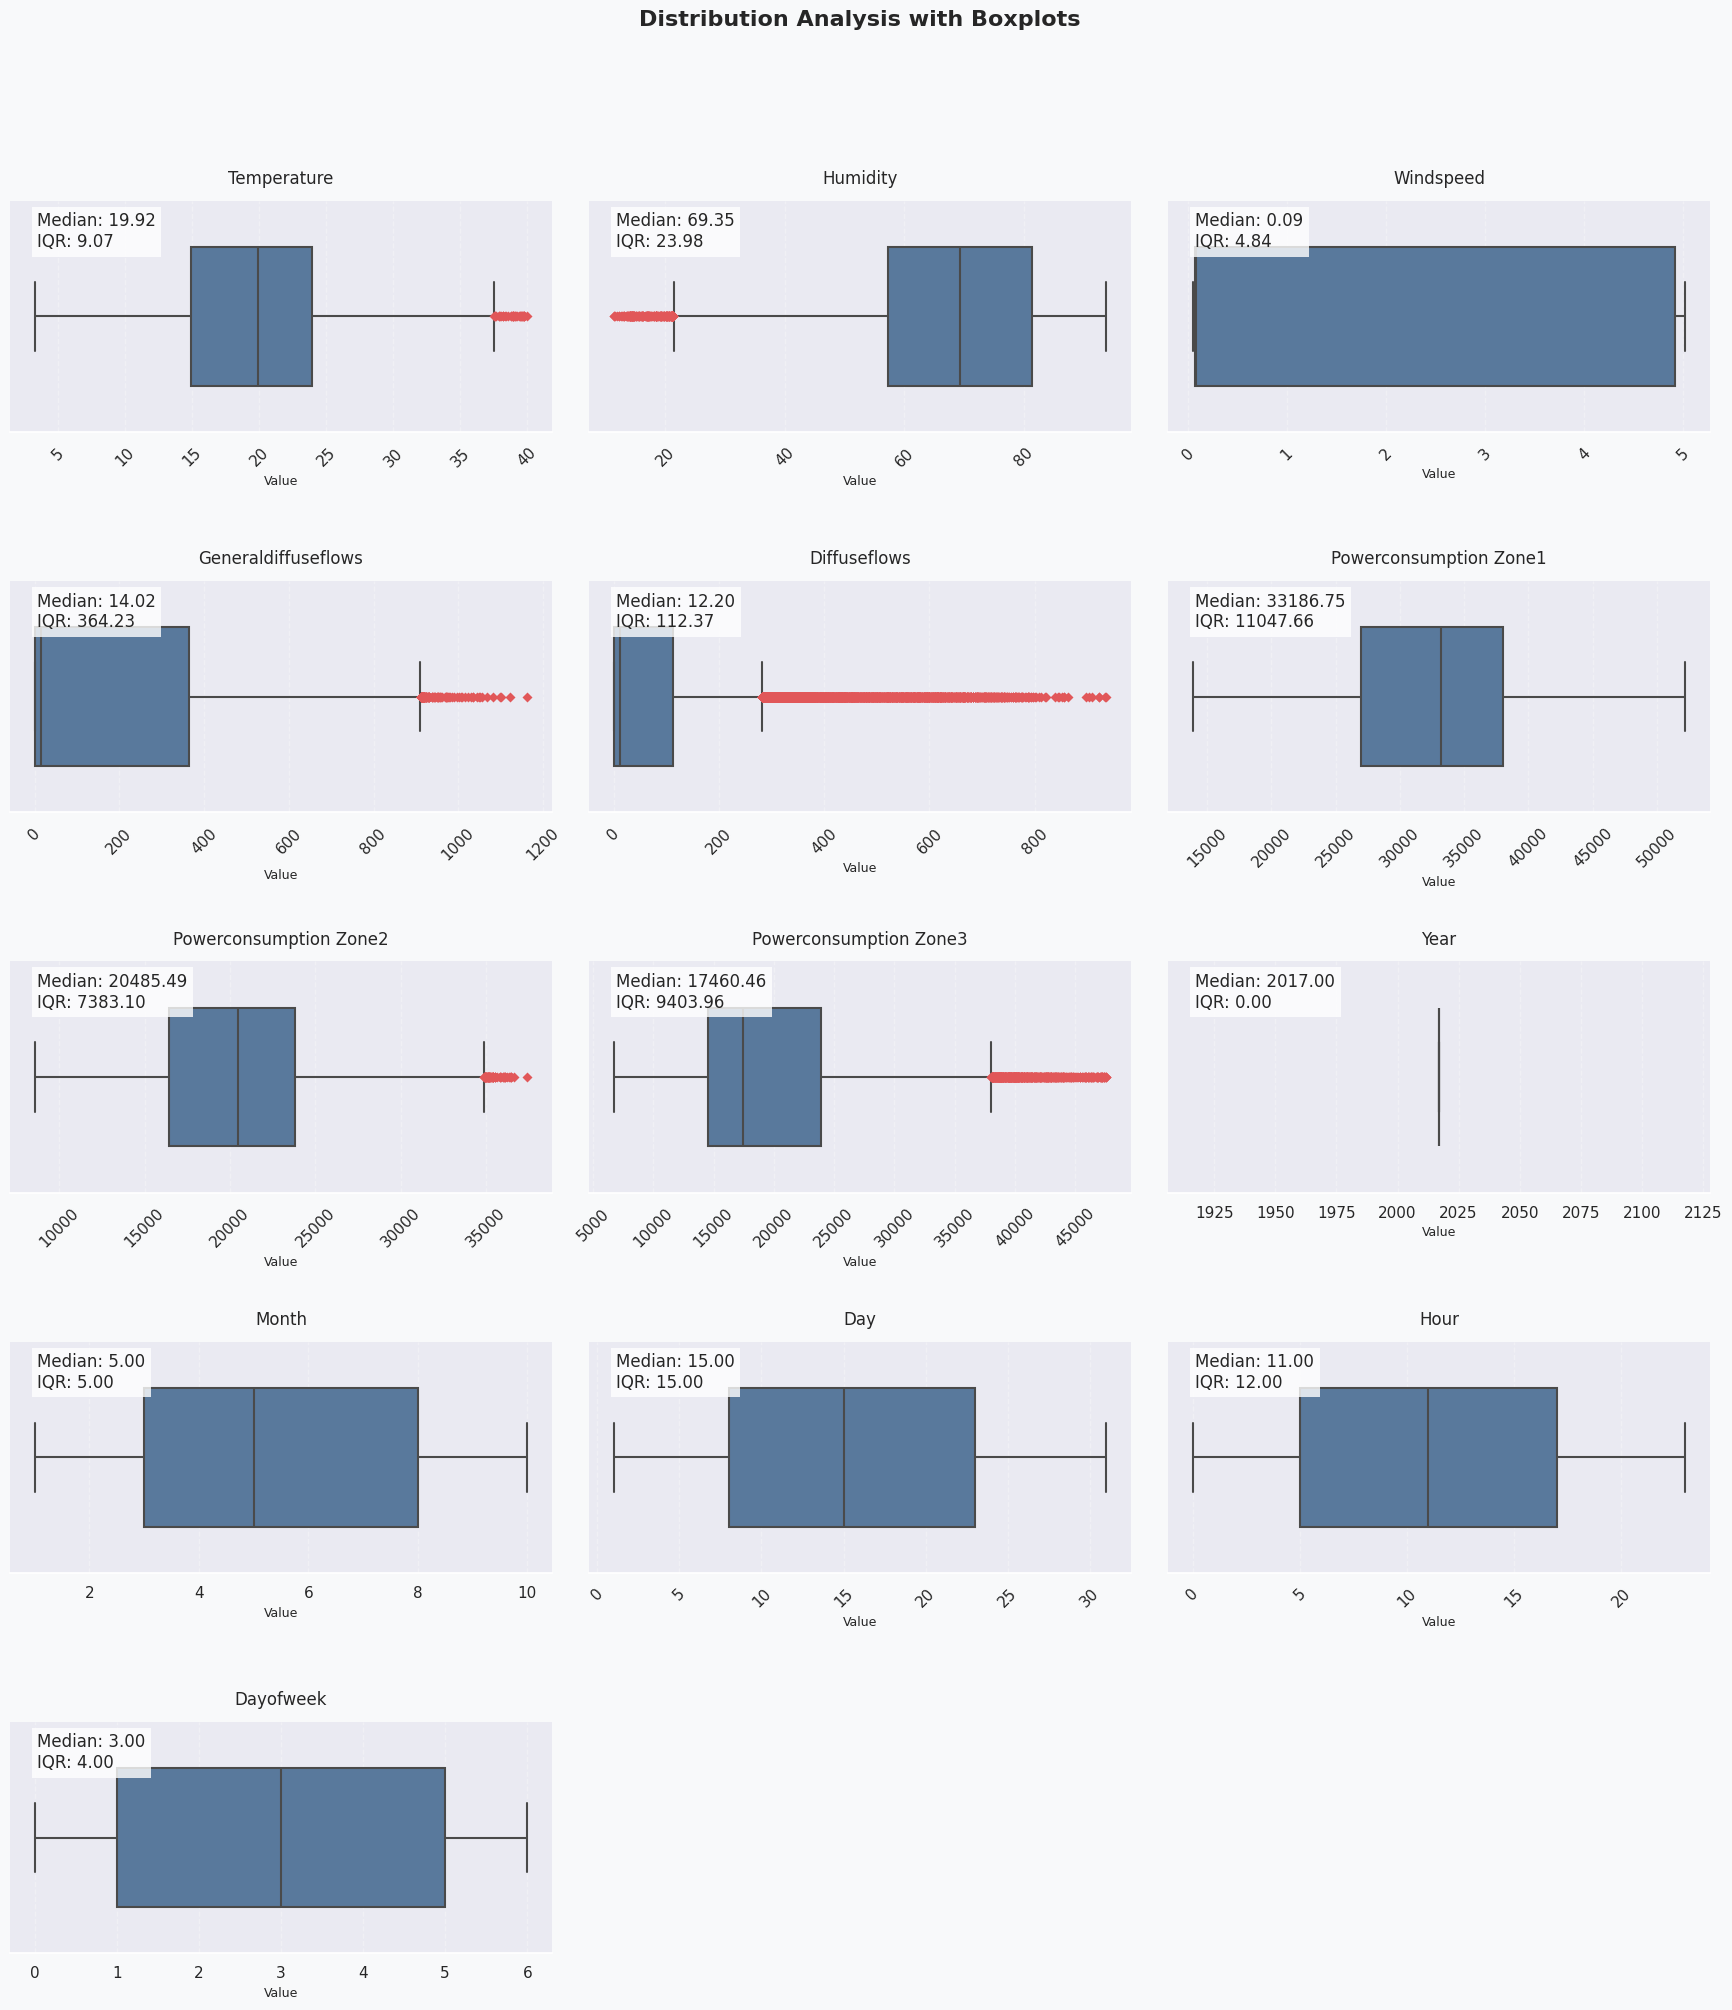

In [16]:

num_cols = len(numeric_columns.columns)
n_cols = 3  # Number of columns in subplot grid
n_rows = math.ceil(num_cols / n_cols)

plt.figure(figsize=(6 * n_cols, 4 * n_rows), facecolor='#f8f9fa')
plt.suptitle('Distribution Analysis with Boxplots', y=1.02, fontsize=16, fontweight='bold')

for i, col in enumerate(numeric_columns.columns, 1):
    ax = plt.subplot(n_rows, n_cols, i)
    
    # Create customized boxplot
    box = sns.boxplot(data=numeric_columns, x=col, 
                     color='#4e79a7',  # Primary box color
                     width=0.6,
                     linewidth=1.5,
                     fliersize=4,  # Outlier marker size
                     flierprops=dict(markerfacecolor='#e15759',  # Outlier color
                                   marker='D',  # Diamond shape
                                   markersize=5,
                                   markeredgecolor='none'))
    
    # Calculate and display key statistics
    median = numeric_columns[col].median()
    q1 = numeric_columns[col].quantile(0.25)
    q3 = numeric_columns[col].quantile(0.75)
    iqr = q3 - q1
    
    # Add statistical annotations
    ax.text(0.05, 0.95, 
           f"Median: {median:.2f}\nIQR: {iqr:.2f}", 
           transform=ax.transAxes,
           verticalalignment='top',
           bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
    
    # Customize title and labels
    plt.title(col.replace('_', ' ').title(), pad=12, fontsize=12)
    plt.xlabel('Value', fontsize=9)
    plt.ylabel('')  # Remove y-label as it's redundant for boxplots
    
    # Custom grid and spines
    plt.grid(axis='x', alpha=0.3, linestyle='--')
    sns.despine(left=True)
    
    # Rotate x-axis labels if needed
    if numeric_columns[col].nunique() > 10:
        plt.xticks(rotation=45)

plt.tight_layout(pad=3.0, h_pad=2.5, w_pad=1.5)
plt.show()

In [17]:


def professional_correlation_analysis(df: pd.DataFrame, target_column: str) -> pd.DataFrame:
    """
    Perform a professional correlation analysis between numeric features and a target column.

    Parameters:
    ----------
    df : pd.DataFrame
        The input DataFrame containing the data.
    target_column : str
        The target column name to compute correlations against.

    Returns:
    -------
    pd.DataFrame
        A formatted DataFrame showing correlation values, strength, and direction.
    """
    # Ensure the target column is numeric
    if target_column not in train_data.select_dtypes(include='number').columns:
        raise ValueError(f"Target column '{target_column}' must be numeric.")

    # Compute correlation with the target column
    numeric_df = train_data.select_dtypes(include='number')
    corr_series = numeric_df.corr()[target_column].drop(labels=[target_column]).sort_values(ascending=False)

    # Create the results DataFrame
    corr_df = pd.DataFrame({
        'Correlation': corr_series,
        'Strength': pd.cut(
            corr_series.abs(),
            bins=[0, 0.3, 0.5, 0.7, 1],
            labels=['Weak', 'Moderate', 'Strong', 'Very Strong'],
            right=False
        ).astype(str),
        'Direction': np.where(corr_series > 0, 'Positive', 'Negative')
    })

    # Format correlation values
    corr_df['Correlation'] = corr_df['Correlation'].round(3)

    return corr_df

# Example Usage
target = 'PowerConsumption_Zone1'
correlation_results = professional_correlation_analysis(train_data, target)

# Optional: Professionally styled output
styled_results = (
    correlation_results
    .style
    .background_gradient(cmap='coolwarm', subset=['Correlation'], vmin=-1, vmax=1)
    .set_caption(f"Correlation Analysis with '{target}'")
    .set_properties(**{'text-align': 'center'})
    .set_table_styles([
        {'selector': 'caption',
         'props': [('font-size', '16px'),
                   ('font-weight', 'bold'),
                   ('text-align', 'center'),
                   ('margin-bottom', '10px')]},
        {'selector': 'th',
         'props': [('background-color', '#f0f0f0'),
                   ('font-weight', 'bold'),
                   ('text-align', 'center')]}
    ])
)
print(correlation_results)

                                Correlation     Strength Direction
PowerConsumption_Zone2                 0.92  Very Strong  Positive
PowerConsumption_Zone3                 0.76  Very Strong  Positive
Hour                                   0.73  Very Strong  Positive
Temperature                            0.42     Moderate  Positive
Month                                  0.21         Weak  Positive
GeneralDiffuseFlows                    0.17         Weak  Positive
WindSpeed                              0.15         Weak  Positive
DiffuseFlows                           0.05         Weak  Positive
Day                                    0.04         Weak  Positive
DayOfWeek                             -0.07         Weak  Negative
Humidity                              -0.28         Weak  Negative
Year                                    NaN          nan  Negative


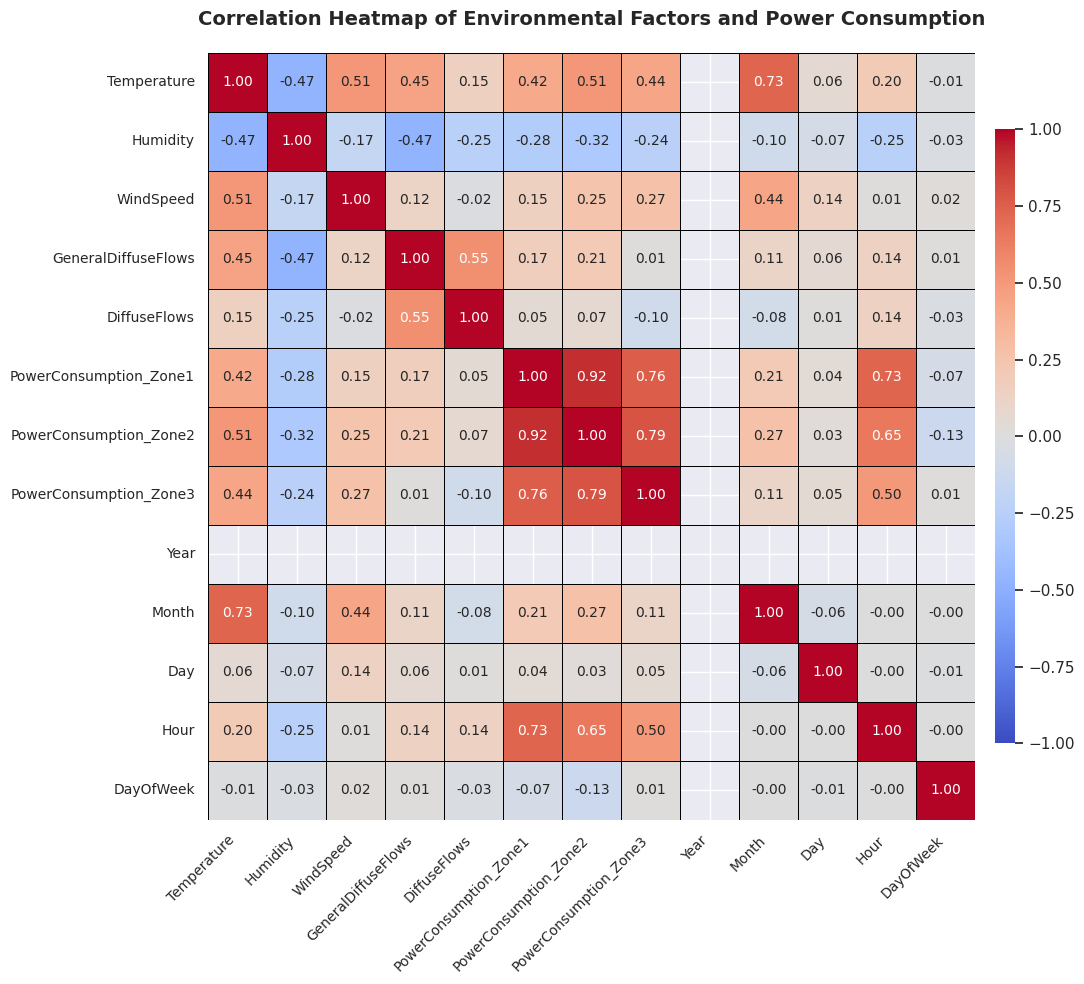

In [18]:
#CORRELATION HEATMAP
plt.figure(figsize=(12, 10))  # Light gray background
# Generate the correlation matrix with absolute values sorted (optional)
corr = numeric_columns.corr().round(2)


# Create the heatmap
sns.heatmap(corr, 
            annot=True, 
            fmt=".2f", 
            cmap='coolwarm', 
            center=0, 
            linewidths=0.7, 
            linecolor='black', 
            cbar_kws={"shrink": 0.8, 'pad': 0.02, 'aspect': 30},
            square=True,
            annot_kws={"size":10},
            vmin=-1, vmax=1)

plt.title('Correlation Heatmap of Environmental Factors and Power Consumption', fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

In [19]:
from IPython.display import display, Markdown

display(Markdown(
    """
### 🔍 Correlation Report

The correlation analysis reveals that **PowerConsumption_Zone1** has a stronger relationship with **PowerConsumption_Zone2** and **PowerConsumption_Zone3** compared to other features. This suggests that power usage patterns in Zone 1 are closely linked to those in Zones 2 and 3, indicating possible shared operational factors or similar demand drivers across these zones.

Below is the detailed correlation analysis table:

"""
))
display(styled_results)


### 🔍 Correlation Report

The correlation analysis reveals that **PowerConsumption_Zone1** has a stronger relationship with **PowerConsumption_Zone2** and **PowerConsumption_Zone3** compared to other features. This suggests that power usage patterns in Zone 1 are closely linked to those in Zones 2 and 3, indicating possible shared operational factors or similar demand drivers across these zones.

Below is the detailed correlation analysis table:



,Correlation,Strength,Direction
PowerConsumption_Zone2,0.921000,Very Strong,Positive
PowerConsumption_Zone3,0.760000,Very Strong,Positive
Hour,0.733000,Very Strong,Positive
Temperature,0.418000,Moderate,Positive
Month,0.213000,Weak,Positive
GeneralDiffuseFlows,0.168000,Weak,Positive
WindSpeed,0.151000,Weak,Positive
DiffuseFlows,0.050000,Weak,Positive
Day,0.038000,Weak,Positive
DayOfWeek,-0.065000,Weak,Negative


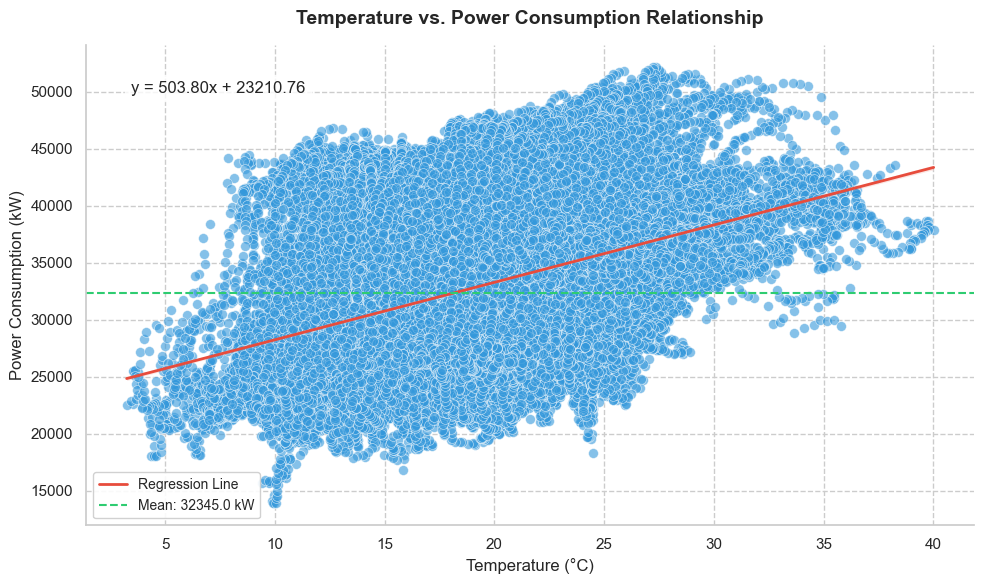

In [20]:
# Set the aesthetic style
sns.set_style("whitegrid", {'grid.linestyle': '--', 'grid.alpha': 0.3})

# Create the regression plot with corrected parameters
plt.figure(figsize=(10, 6))
g = sns.regplot(
    x='Temperature', 
    y='PowerConsumption_Zone1', 
    data=train_data,
    scatter_kws={
        'alpha': 0.6,
        's': 50,  # Marker size
        'color': '#3498db',  # Marker fill color
        'edgecolor': 'white',  # Marker edge color
        'linewidths': 0.5  # Marker edge width (use only linewidths, not linewidth)
    },
    line_kws={
        'color': '#e74c3c',  # Regression line color
        'linewidth': 2,  # Regression line width
        'label': 'Regression Line'
    },
    ci=95  # Confidence interval
)

#  the plot
plt.xlabel('Temperature (°C)', fontsize=12)
plt.ylabel('Power Consumption (kW)', fontsize=12)
plt.title('Temperature vs. Power Consumption Relationship', 
         fontsize=14, pad=15, fontweight='bold')

# Add mean reference line
mean_power = df['PowerConsumption_Zone1'].mean()
plt.axhline(mean_power, color='#2ecc71', linestyle='--', 
            linewidth=1.5, label=f'Mean: {mean_power:.1f} kW')

# Add regression equation
slope, intercept = np.polyfit(train_data['Temperature'], train_data['PowerConsumption_Zone1'], 1)
plt.text(0.05, 0.9, 
         f'y = {slope:.2f}x + {intercept:.2f}', 
         transform=g.transAxes,
         fontsize=12,
         bbox=dict(facecolor='white', alpha=0.8))

# Customize legend and layout
plt.legend(fontsize=10, frameon=True, framealpha=0.9)
sns.despine()
plt.tight_layout()
plt.show()

In [21]:

train_data.drop(columns=['Season','Month_Name','DayOfWeek_Name'], inplace=True) # dropping this , it was for analysis purposes (reason we want train data to match test data   )
print("Columns in the training dataset:")
display(train_data.columns, train_data.shape)

print("Columns in the testing dataset:")
display(test_data.columns , test_data.shape)

Columns in the training dataset:


Index(['Datetime', 'Temperature', 'Humidity', 'WindSpeed',
       'GeneralDiffuseFlows', 'DiffuseFlows', 'PowerConsumption_Zone1',
       'PowerConsumption_Zone2', 'PowerConsumption_Zone3', 'Year', 'Month',
       'Day', 'Hour', 'DayOfWeek', 'Is_Weekend'],
      dtype='object')

(41932, 15)

Columns in the testing dataset:


Index(['Datetime', 'Temperature', 'Humidity', 'WindSpeed',
       'GeneralDiffuseFlows', 'DiffuseFlows', 'PowerConsumption_Zone1',
       'PowerConsumption_Zone2', 'PowerConsumption_Zone3', 'Year', 'Month',
       'Day', 'Hour', 'DayOfWeek'],
      dtype='object')

(10484, 14)

## 🚀 Model Development

This section documents the process of building, evaluating, and refining predictive models for power consumption forecasting in Zone 1.

##  Baseline Feature Engineering 

In [22]:
# -----------------------------
# 1 Encode features in train_data
# -----------------------------

# Is_Weekend → boolean → int
train_data['Is_Weekend'] = train_data['Is_Weekend'].astype(int)


In [23]:
# -----------------------------
# 1 Feature Engineering on Test Data
# -----------------------------

# Convert Datetime
test_data['Datetime'] = pd.to_datetime(test_data['Datetime'])

# Is_Weekend → boolean → int
test_data['Is_Weekend'] = test_data['DayOfWeek'].isin([5,6]).astype(int)

In [24]:
def create_safe_features_only(df, target_col='PowerConsumption_Zone1', date_col='Datetime'):
    """
    Create ONLY safe features without any data leakage
    No lag features, no rolling statistics - only basic temporal and weather features
    """
    df_clean = df.copy()
    
    # Ensure we have datetime index for proper time series handling
    if date_col in df_clean.columns:
        df_clean[date_col] = pd.to_datetime(df_clean[date_col])
        df_clean = df_clean.set_index(date_col)
    
    # 2. Business logic features (completely safe)
    df_clean['Is_Weekend'] = df_clean['DayOfWeek'].isin([5, 6]).astype(int)
    df_clean['Is_Night'] = ((df_clean['Hour'] >= 22) | (df_clean['Hour'] <= 6)).astype(int)
    df_clean['Is_Working_Hours'] = (
        (df_clean['Hour'] >= 8) & 
        (df_clean['Hour'] <= 18) & 
        (df_clean['DayOfWeek'] < 5)
    ).astype(int)

    
    print(f" Created {len([col for col in df_clean.columns if col != target_col])} SAFE features")
    print(f" Dataset shape: {df_clean.shape}")
    print(" NO lag features, NO rolling statistics - completely leak-proof")
    
    return df_clean

In [25]:
def prepare_safe_datasets_chronological(train_data, test_data, target_col='PowerConsumption_Zone1', date_col='Datetime', validation_size=0.2):
    """
    Prepare datasets using ONLY safe features - no data leakage possible
    Works with pre-existing chronological train-test split
    Returns: X_train, X_val, X_test, y_train, y_val, y_test, feature_columns
    """
    print(" Preparing LEAK-PROOF datasets with chronological Train/Validation/Test split...")
    
    # 1. Create safe features for both train and test
    train_features = create_safe_features_only(train_data, target_col, date_col)
    test_features = create_safe_features_only(test_data, target_col, date_col)
    
    # 2. Define SAFE feature columns (EXCLUDE other power zones and datetime/target)
    exclude_cols = [target_col, date_col]
    
    # Get all numeric columns that are not in exclude_cols
    feature_columns = [col for col in train_features.columns 
                      if col not in exclude_cols 
                      and pd.api.types.is_numeric_dtype(train_features[col])]
    
    print(f" Using {len(feature_columns)} completely safe features:")
    for i, feature in enumerate(feature_columns, 1):
        print(f"   {i:2d}. {feature}")
    
    # 3. Prepare features and target
    X_full_train = train_features[feature_columns]
    y_full_train = train_features[target_col]
    
    X_test = test_features[feature_columns]
    y_test = test_features[target_col] if target_col in test_features.columns else None
    
    # 4. Split training data chronologically into train and validation
    # Since your data is already sorted chronologically, we split the training portion
    split_idx = int(len(X_full_train) * (1 - validation_size))
    
    X_train = X_full_train.iloc[:split_idx]
    X_val = X_full_train.iloc[split_idx:]
    y_train = y_full_train.iloc[:split_idx]
    y_val = y_full_train.iloc[split_idx:]
    
    print(f"\n Final dataset sizes:")
    print(f"   Training: {X_train.shape} (earliest {int((1-validation_size)*100)}% of training period)")
    print(f"   Validation: {X_val.shape} (latest {int(validation_size*100)}% of training period)")
    print(f"   Test: {X_test.shape} (future period)")
    
    # Print date ranges if datetime column is available
    if date_col in train_features.columns:
        print(f"\n Date ranges:")
        print(f"   Training: {train_features[date_col].iloc[0]} to {train_features[date_col].iloc[split_idx-1]}")
        print(f"   Validation: {train_features[date_col].iloc[split_idx]} to {train_features[date_col].iloc[-1]}")
        if date_col in test_features.columns:
            print(f"   Test: {test_features[date_col].iloc[0]} to {test_features[date_col].iloc[-1]}")
    
    # 5. Final dtype check
    print(f"\n Data types:")
    print(X_train.dtypes.value_counts())
    
    return X_train, X_val, X_test, y_train, y_val, y_test, feature_columns

# existing train_data and test_data
X_train, X_val, X_test, y_train, y_val, y_test, features = prepare_safe_datasets_chronological(
    train_data, 
    test_data, 
    target_col='PowerConsumption_Zone1',
    validation_size=0.2  # Adjust this as needed
)

total_len = len(train_data) + len(test_data)
print(f"\nFinal split ratios (relative to full dataset):")
print(f"Train: {len(X_train)/total_len:.1%}")
print(f"Val: {len(X_val)/total_len:.1%}")
print(f"Test: {len(X_test)/total_len:.1%}")


 Preparing LEAK-PROOF datasets with chronological Train/Validation/Test split...
 Created 15 SAFE features
 Dataset shape: (41932, 16)
 NO lag features, NO rolling statistics - completely leak-proof
 Created 15 SAFE features
 Dataset shape: (10484, 16)
 NO lag features, NO rolling statistics - completely leak-proof
 Using 15 completely safe features:
    1. Temperature
    2. Humidity
    3. WindSpeed
    4. GeneralDiffuseFlows
    5. DiffuseFlows
    6. PowerConsumption_Zone2
    7. PowerConsumption_Zone3
    8. Year
    9. Month
   10. Day
   11. Hour
   12. DayOfWeek
   13. Is_Weekend
   14. Is_Night
   15. Is_Working_Hours

 Final dataset sizes:
   Training: (33545, 15) (earliest 80% of training period)
   Validation: (8387, 15) (latest 20% of training period)
   Test: (10484, 15) (future period)

 Data types:
float64    7
int32      5
int64      3
Name: count, dtype: int64

Final split ratios (relative to full dataset):
Train: 64.0%
Val: 16.0%
Test: 20.0%


RUNNING BASELINE MODELS WITH PREPARED DATA
BUILDING BASELINE MODELS

1. PERSISTENCE MODEL (Naive Forecast)
Persistence (Val) Results:
  MAE: 9808.50
  RMSE: 11227.25
  MSE: 126051189.41
  R²: -1.8517
  MAPE: 33.29%
--------------------------------------------------

2. MEAN BASELINE
Mean Baseline (Val) Results:
  MAE: 5558.78
  RMSE: 6721.53
  MSE: 45179032.48
  R²: -0.0221
  MAPE: 16.56%
--------------------------------------------------

3. MEDIAN BASELINE
Median Baseline (Val) Results:
  MAE: 5544.32
  RMSE: 6699.79
  MSE: 44887191.70
  R²: -0.0155
  MAPE: 16.60%
--------------------------------------------------

4. LINEAR REGRESSION
Linear Regression (Val) Results:
  MAE: 3174.31
  RMSE: 3661.55
  MSE: 13406919.74
  R²: 0.6967
  MAPE: 9.30%
--------------------------------------------------

5. RIDGE REGRESSION
Ridge Regression (Val) Results:
  MAE: 3174.51
  RMSE: 3661.76
  MSE: 13408482.39
  R²: 0.6967
  MAPE: 9.30%
--------------------------------------------------

6. RANDOM F

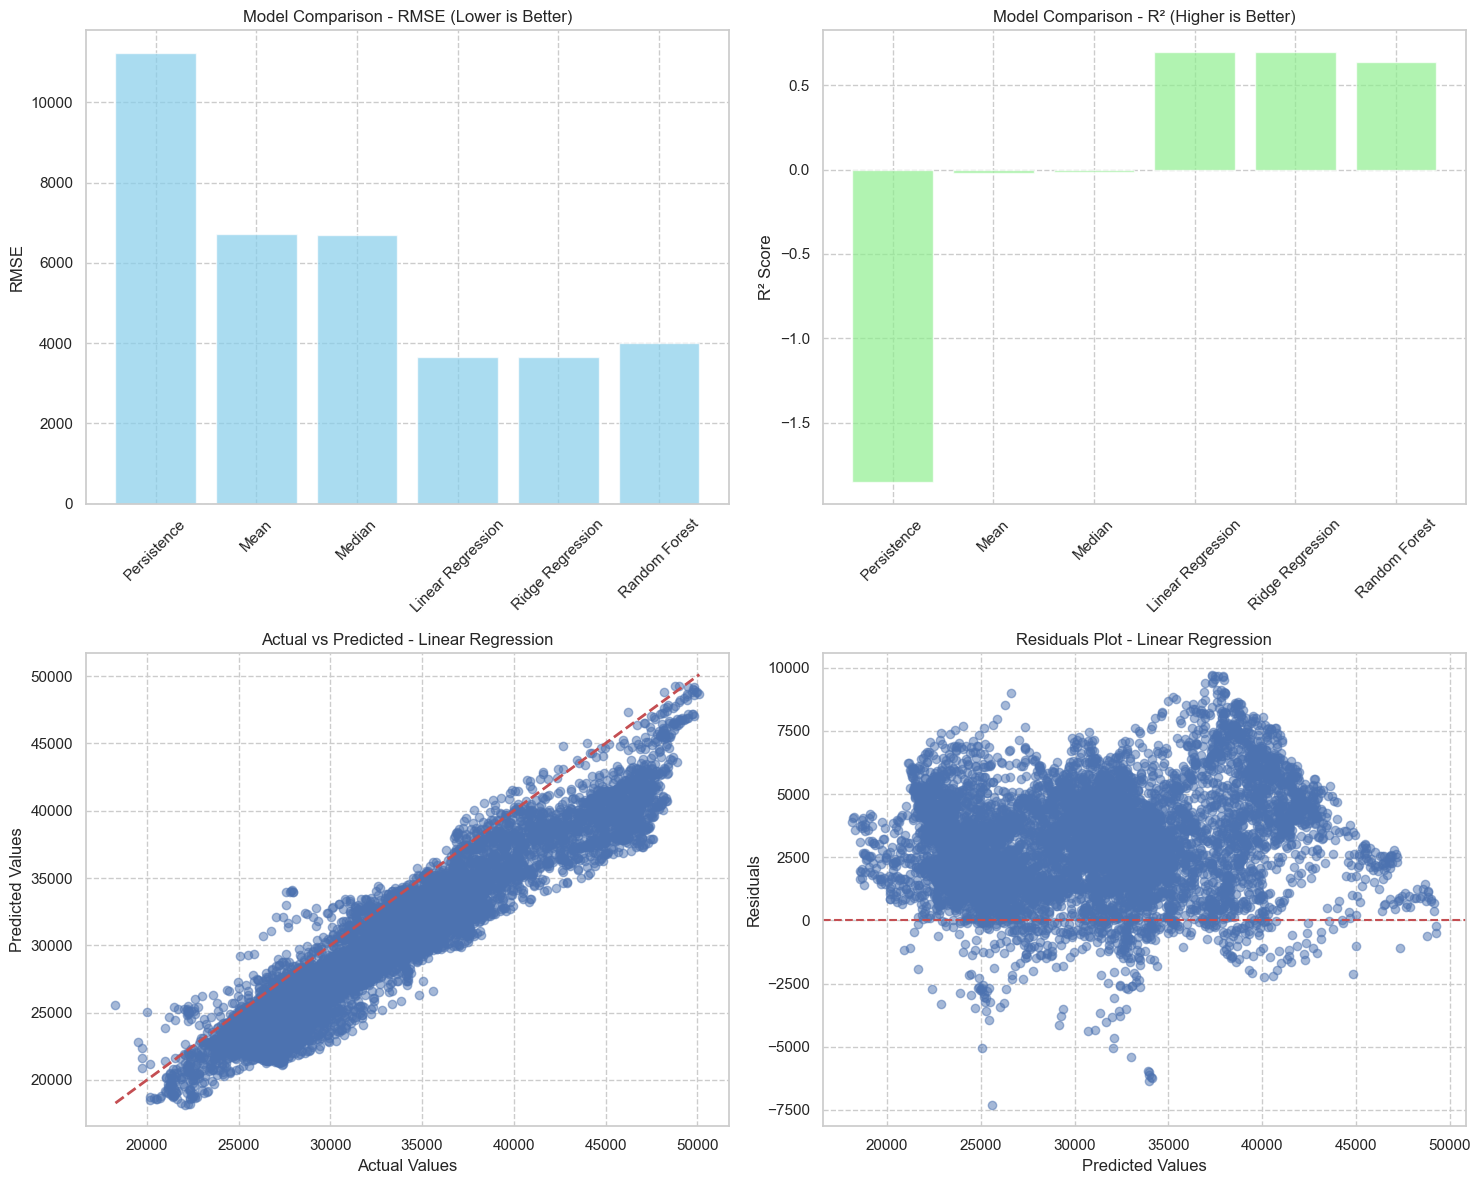


FINAL TEST SET EVALUATION
Best Model - Test Set Results:
  MAE: 3893.69
  RMSE: 4218.00
  MSE: 17791550.61
  R²: 0.5321
  MAPE: 13.41%
--------------------------------------------------

VALIDATION vs TEST PERFORMANCE
Validation RMSE: 3661.5461
Test RMSE: 4218.0032
Validation R²: 0.6967
Test R²: 0.5321

Performance Change from Validation to Test:
RMSE change: +556.4571 (+15.2%)
R² change: -0.1646

BASELINE MODELING COMPLETE


In [26]:

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler

def evaluate_model(y_true, y_pred, model_name=""):
    """Comprehensive model evaluation"""
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    
    # Mean Absolute Percentage Error (MAPE)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    
    print(f"{model_name} Results:")
    print(f"  MAE: {mae:.2f}")
    print(f"  RMSE: {rmse:.2f}")
    print(f"  MSE: {mse:.2f}")
    print(f"  R²: {r2:.4f}")
    print(f"  MAPE: {mape:.2f}%")
    print("-" * 50)
    
    return {'MAE': mae, 'RMSE': rmse, 'MSE': mse, 'R2': r2, 'MAPE': mape}

def build_baseline_models(X_train, X_val, X_test, y_train, y_val, y_test, feature_columns):
    """
    Build multiple baseline models for comparison
    """
    print("=" * 80)
    print("BUILDING BASELINE MODELS")
    print("=" * 80)
    
    results = {}
    
    # 1. Simple Persistence Model (naive forecast)
    print("\n1. PERSISTENCE MODEL (Naive Forecast)")
    # For time series: next value = current value
    if len(X_val) > 0:
        # If we have temporal structure, use persistence
        y_val_persistence = y_train.iloc[-1]  # Last training value for all validation
        if isinstance(y_val_persistence, (pd.Series, np.ndarray)) and len(y_val_persistence) > 1:
            y_val_persistence = y_train.iloc[-1]  # Single value
        persistence_val = np.full_like(y_val, y_val_persistence)
        results['Persistence'] = evaluate_model(y_val, persistence_val, "Persistence (Val)")
    
    # 2. Mean Baseline
    print("\n2. MEAN BASELINE")
    mean_target = y_train.mean()
    mean_val = np.full_like(y_val, mean_target)
    results['Mean'] = evaluate_model(y_val, mean_val, "Mean Baseline (Val)")
    
    # 3. Median Baseline
    print("\n3. MEDIAN BASELINE")
    median_target = y_train.median()
    median_val = np.full_like(y_val, median_target)
    results['Median'] = evaluate_model(y_val, median_val, "Median Baseline (Val)")
    
    # 4. Linear Regression
    print("\n4. LINEAR REGRESSION")
    # Scale features for linear models
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)
    
    lr = LinearRegression()
    lr.fit(X_train_scaled, y_train)
    
    y_val_lr = lr.predict(X_val_scaled)
    results['Linear Regression'] = evaluate_model(y_val, y_val_lr, "Linear Regression (Val)")
    
    # 5. Ridge Regression
    print("\n5. RIDGE REGRESSION")
    ridge = Ridge(alpha=1.0, random_state=42)
    ridge.fit(X_train_scaled, y_train)
    
    y_val_ridge = ridge.predict(X_val_scaled)
    results['Ridge Regression'] = evaluate_model(y_val, y_val_ridge, "Ridge Regression (Val)")
    
    # 6. Random Forest (simple)
    print("\n6. RANDOM FOREST BASELINE")
    rf = RandomForestRegressor(
        n_estimators=100,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    )
    rf.fit(X_train, y_train)
    
    y_val_rf = rf.predict(X_val)
    results['Random Forest'] = evaluate_model(y_val, y_val_rf, "Random Forest (Val)")
    
    # Feature Importance for Random Forest
    feature_importance = pd.DataFrame({
        'feature': feature_columns,
        'importance': rf.feature_importances_
    }).sort_values('importance', ascending=False)
    
    print("\nTop 10 Most Important Features (Random Forest):")
    print(feature_importance.head(10).to_string(index=False))
    
    # 7. Compare all models
    print("\n" + "=" * 80)
    print("MODEL COMPARISON (Validation Set)")
    print("=" * 80)
    
    comparison_df = pd.DataFrame(results).T
    comparison_df = comparison_df.sort_values('RMSE')
    print(comparison_df.round(4))
    
    return results, lr, ridge, rf, scaler, feature_importance, comparison_df

def plot_baseline_results(results, y_val, best_model_predictions, best_model_name):
    """Plot baseline model comparisons"""
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # 1. RMSE comparison
    rmse_values = [results[model]['RMSE'] for model in results]
    model_names = list(results.keys())
    
    axes[0, 0].bar(model_names, rmse_values, color='skyblue', alpha=0.7)
    axes[0, 0].set_title('Model Comparison - RMSE (Lower is Better)')
    axes[0, 0].set_ylabel('RMSE')
    axes[0, 0].tick_params(axis='x', rotation=45)
    
    # 2. R² comparison
    r2_values = [results[model]['R2'] for model in results]
    
    axes[0, 1].bar(model_names, r2_values, color='lightgreen', alpha=0.7)
    axes[0, 1].set_title('Model Comparison - R² (Higher is Better)')
    axes[0, 1].set_ylabel('R² Score')
    axes[0, 1].tick_params(axis='x', rotation=45)
    
    # 3. Actual vs Predicted for best model
    axes[1, 0].scatter(y_val, best_model_predictions, alpha=0.5)
    axes[1, 0].plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=2)
    axes[1, 0].set_xlabel('Actual Values')
    axes[1, 0].set_ylabel('Predicted Values')
    axes[1, 0].set_title(f'Actual vs Predicted - {best_model_name}')
    
    # 4. Residuals plot for best model
    residuals = y_val - best_model_predictions
    axes[1, 1].scatter(best_model_predictions, residuals, alpha=0.5)
    axes[1, 1].axhline(y=0, color='r', linestyle='--')
    axes[1, 1].set_xlabel('Predicted Values')
    axes[1, 1].set_ylabel('Residuals')
    axes[1, 1].set_title(f'Residuals Plot - {best_model_name}')
    
    plt.tight_layout()
    plt.show()

def test_best_model(best_model, X_test, y_test, scaler=None, model_type='random_forest'):
    """Evaluate the best model on test set"""
    print("\n" + "=" * 80)
    print("FINAL TEST SET EVALUATION")
    print("=" * 80)
    
    if scaler is not None and model_type in ['linear', 'ridge']:
        X_test_scaled = scaler.transform(X_test)
        y_test_pred = best_model.predict(X_test_scaled)
    else:
        y_test_pred = best_model.predict(X_test)
    
    test_results = evaluate_model(y_test, y_test_pred, "Best Model - Test Set")
    return test_results, y_test_pred

# Main execution - using the data you already prepared
print("=" * 80)
print("RUNNING BASELINE MODELS WITH PREPARED DATA")
print("=" * 80)

# Build baseline models with the data you already prepared
results, lr, ridge, rf, scaler, feature_importance, comparison_df = build_baseline_models(
    X_train, X_val, X_test, y_train, y_val, y_test, features
)

# Identify best model based on validation RMSE
best_model_name = comparison_df.index[0]
print(f"\n BEST BASELINE MODEL: {best_model_name}")
print(f"Validation RMSE: {comparison_df.iloc[0]['RMSE']:.4f}")
print(f"Validation R²: {comparison_df.iloc[0]['R2']:.4f}")

# Get the best model and its predictions
if best_model_name == 'Linear Regression':
    best_model = lr
    best_predictions = lr.predict(scaler.transform(X_val))
    model_type = 'linear'
elif best_model_name == 'Ridge Regression':
    best_model = ridge
    best_predictions = ridge.predict(scaler.transform(X_val))
    model_type = 'ridge'
elif best_model_name == 'Random Forest':
    best_model = rf
    best_predictions = rf.predict(X_val)
    model_type = 'random_forest'
else:
    # For simple baselines, we don't have a model object
    best_model = None
    best_predictions = None
    print(f"Note: {best_model_name} is a simple baseline without model object")

# Plot results if we have a proper model
if best_model is not None:
    plot_baseline_results(results, y_val, best_predictions, best_model_name)
    
    # Final test set evaluation
    test_results, y_test_pred = test_best_model(best_model, X_test, y_test, scaler, model_type)
    
    # Compare validation vs test performance
    print("\n" + "=" * 80)
    print("VALIDATION vs TEST PERFORMANCE")
    print("=" * 80)
    print(f"Validation RMSE: {comparison_df.iloc[0]['RMSE']:.4f}")
    print(f"Test RMSE: {test_results['RMSE']:.4f}")
    print(f"Validation R²: {comparison_df.iloc[0]['R2']:.4f}")
    print(f"Test R²: {test_results['R2']:.4f}")
    
    # Performance difference
    rmse_diff = test_results['RMSE'] - comparison_df.iloc[0]['RMSE']
    r2_diff = test_results['R2'] - comparison_df.iloc[0]['R2']
    print(f"\nPerformance Change from Validation to Test:")
    print(f"RMSE change: {rmse_diff:+.4f} ({rmse_diff/comparison_df.iloc[0]['RMSE']:+.1%})")
    print(f"R² change: {r2_diff:+.4f}")
else:
    print(f"\nSkipping test set evaluation for baseline model: {best_model_name}")

print("\n" + "=" * 80)
print("BASELINE MODELING COMPLETE")
print("=" * 80)

RUNNING ADVANCED MODELS COMPARISON
BUILDING ADVANCED MODELS: LightGBM, XGBoost, Gradient Boosting, Random Forest

 1. LIGHTGBM MODEL
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[50]	valid_0's rmse: 3396.72	valid_0's l2: 1.15377e+07
LightGBM (Val) Results:
  MAE: 2554.78
  RMSE: 3396.72
  R²: 0.7390
  MAPE: 6.98%
  MBE: -2294.41 (bias: under-prediction)
  Relative RMSE: 10.03%
------------------------------------------------------------

 2. XGBOOST MODEL
Standard version failed: XGBModel.fit() got an unexpected keyword argument 'early_stopping_rounds'
Trying safe version...
BUILDING ADVANCED MODELS: LightGBM, XGBoost, Gradient Boosting, Random Forest

 1. LIGHTGBM MODEL
LightGBM (Val) Results:
  MAE: 3487.97
  RMSE: 4206.48
  R²: 0.5997
  MAPE: 9.91%
  MBE: -3362.92 (bias: under-prediction)
  Relative RMSE: 12.42%
------------------------------------------------------------

 2. XGBOOST MODEL
XGBoost (Val) Results:
  MAE: 3382.95
  RM

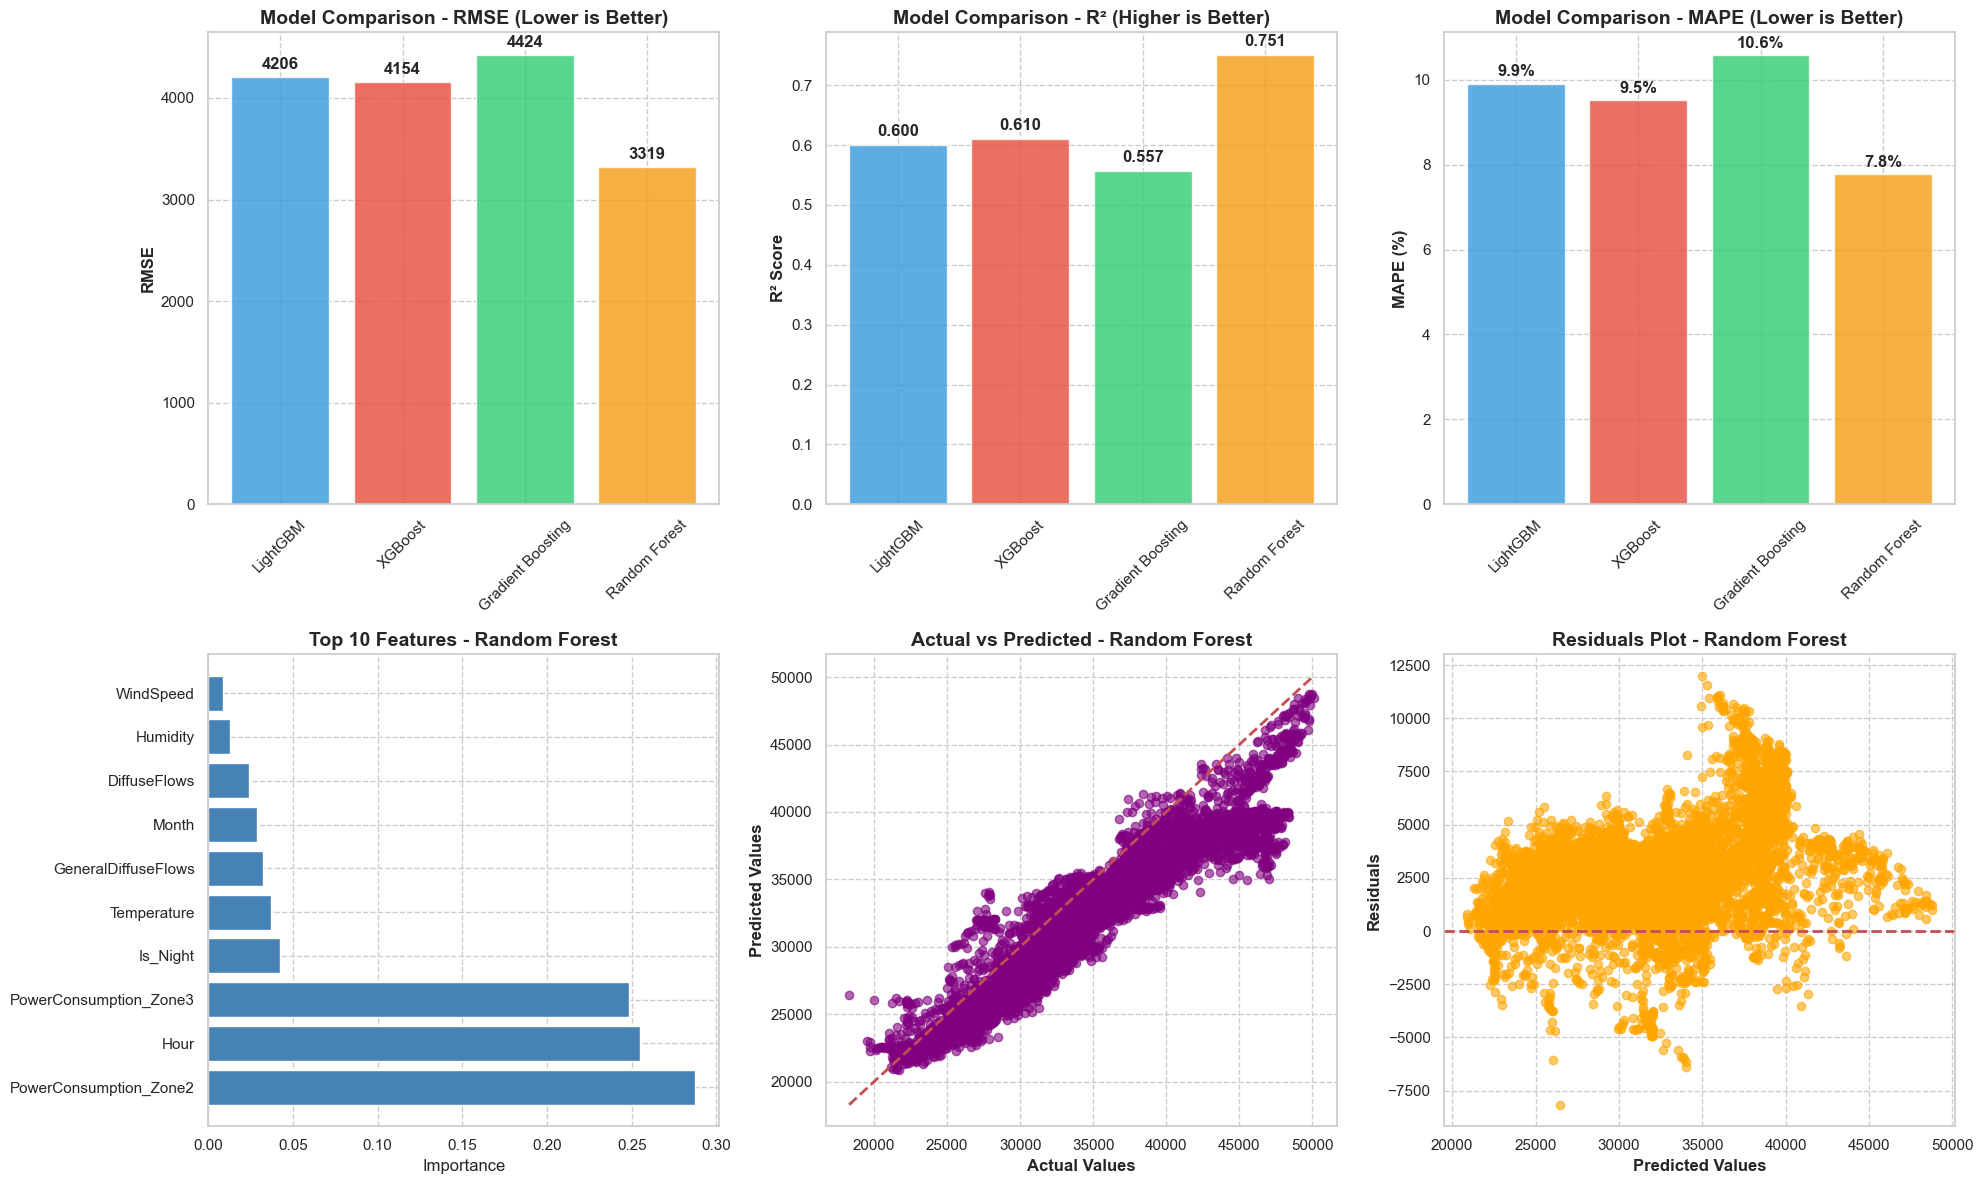


FINAL TEST SET EVALUATION - ALL MODELS

 LightGBM - Test Set Performance:
LightGBM (Test) Results:
  MAE: 2421.82
  RMSE: 2944.18
  R²: 0.7720
  MAPE: 8.56%
  MBE: 1017.75 (bias: over-prediction)
  Relative RMSE: 9.99%
------------------------------------------------------------

 XGBoost - Test Set Performance:
XGBoost (Test) Results:
  MAE: 2636.20
  RMSE: 3185.31
  R²: 0.7332
  MAPE: 9.27%
  MBE: 1142.88 (bias: over-prediction)
  Relative RMSE: 10.81%
------------------------------------------------------------

 Gradient Boosting - Test Set Performance:
Gradient Boosting (Test) Results:
  MAE: 2605.49
  RMSE: 3355.45
  R²: 0.7039
  MAPE: 8.89%
  MBE: 209.27 (bias: over-prediction)
  Relative RMSE: 11.39%
------------------------------------------------------------

 Random Forest - Test Set Performance:
Random Forest (Test) Results:
  MAE: 2560.31
  RMSE: 2904.91
  R²: 0.7781
  MAPE: 9.30%
  MBE: 1630.48 (bias: over-prediction)
  Relative RMSE: 9.86%
------------------------------

In [27]:

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import RandomizedSearchCV
import lightgbm as lgb
import xgboost as xgb


def evaluate_model_advanced(y_true, y_pred, dataset_name=""):
    """Comprehensive model evaluation with additional metrics"""
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    
    # Mean Absolute Percentage Error (MAPE)
    mape = np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), 1e-8))) * 100
    
    # Calculate additional metrics
    mbe = np.mean(y_pred - y_true)  # Mean Bias Error
    relative_rmse = rmse / np.mean(y_true) * 100  # Relative RMSE as percentage
    
    print(f"{dataset_name} Results:")
    print(f"  MAE: {mae:.2f}")
    print(f"  RMSE: {rmse:.2f}")
    print(f"  R²: {r2:.4f}")
    print(f"  MAPE: {mape:.2f}%")
    print(f"  MBE: {mbe:.2f} (bias: {'over' if mbe > 0 else 'under'}-prediction)")
    print(f"  Relative RMSE: {relative_rmse:.2f}%")
    print("-" * 60)
    
    return {
        'MAE': mae, 'RMSE': rmse, 'MSE': mse, 'R2': r2, 
        'MAPE': mape, 'MBE': mbe, 'Relative_RMSE': relative_rmse
    }

def build_advanced_models(X_train, X_val, X_test, y_train, y_val, y_test, feature_columns):
    """
    Build advanced tree-based models with hyperparameter tuning
    """
    print("=" * 80)
    print("BUILDING ADVANCED MODELS: LightGBM, XGBoost, Gradient Boosting, Random Forest")
    print("=" * 80)
    
    results = {}
    models = {}
    feature_importances = {}
    
    # 1. LightGBM
    print("\n 1. LIGHTGBM MODEL")
    lgb_model = lgb.LGBMRegressor(
        n_estimators=1000,
        learning_rate=0.05,
        max_depth=8,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )
    
    # Train with early stopping - CORRECTED PARAMETERS
    lgb_model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        eval_metric='rmse',
        callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(0)]  # Corrected early stopping
    )
    
    y_val_lgb = lgb_model.predict(X_val)
    results['LightGBM'] = evaluate_model_advanced(y_val, y_val_lgb, "LightGBM (Val)")
    models['LightGBM'] = lgb_model
    
    # Feature importance
    feature_importances['LightGBM'] = pd.DataFrame({
        'feature': feature_columns,
        'importance': lgb_model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    # 2. XGBoost
    print("\n 2. XGBOOST MODEL")
    xgb_model = xgb.XGBRegressor(
        n_estimators=1000,
        learning_rate=0.05,
        max_depth=8,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    )
    
    # Train with early stopping
    xgb_model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        early_stopping_rounds=50,
        verbose=False
    )
    
    y_val_xgb = xgb_model.predict(X_val)
    results['XGBoost'] = evaluate_model_advanced(y_val, y_val_xgb, "XGBoost (Val)")
    models['XGBoost'] = xgb_model
    
    # Feature importance
    feature_importances['XGBoost'] = pd.DataFrame({
        'feature': feature_columns,
        'importance': xgb_model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    # 3. Gradient Boosting
    print("\n 3. GRADIENT BOOSTING MODEL")
    gb_model = GradientBoostingRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        random_state=42
    )
    
    gb_model.fit(X_train, y_train)
    y_val_gb = gb_model.predict(X_val)
    results['Gradient Boosting'] = evaluate_model_advanced(y_val, y_val_gb, "Gradient Boosting (Val)")
    models['Gradient Boosting'] = gb_model
    
    # Feature importance
    feature_importances['Gradient Boosting'] = pd.DataFrame({
        'feature': feature_columns,
        'importance': gb_model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    # 4. Improved Random Forest
    print("\n 4. IMPROVED RANDOM FOREST")
    rf_model = RandomForestRegressor(
        n_estimators=500,
        max_depth=15,
        min_samples_split=5,
        min_samples_leaf=2,
        max_features='sqrt',
        bootstrap=True,
        random_state=42,
        n_jobs=-1
    )
    
    rf_model.fit(X_train, y_train)
    y_val_rf = rf_model.predict(X_val)
    results['Random Forest'] = evaluate_model_advanced(y_val, y_val_rf, "Random Forest (Val)")
    models['Random Forest'] = rf_model
    
    # Feature importance
    feature_importances['Random Forest'] = pd.DataFrame({
        'feature': feature_columns,
        'importance': rf_model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    # Compare all models
    print("\n" + "=" * 80)
    print("MODEL COMPARISON (Validation Set)")
    print("=" * 80)
    
    comparison_df = pd.DataFrame(results).T
    comparison_df = comparison_df.sort_values('RMSE')
    print(comparison_df.round(4))
    
    return results, models, feature_importances, comparison_df

def plot_advanced_results(results, models, feature_importances, X_val, y_val):
    """Plot comprehensive results for all models"""
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    
    # 1. RMSE comparison
    rmse_values = [results[model]['RMSE'] for model in results]
    model_names = list(results.keys())
    
    bars = axes[0, 0].bar(model_names, rmse_values, color=['#3498db', '#e74c3c', '#2ecc71', '#f39c12'], alpha=0.8)
    axes[0, 0].set_title('Model Comparison - RMSE (Lower is Better)', fontsize=14, fontweight='bold')
    axes[0, 0].set_ylabel('RMSE', fontweight='bold')
    axes[0, 0].tick_params(axis='x', rotation=45)
    
    # Add value labels on bars
    for bar, value in zip(bars, rmse_values):
        axes[0, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, 
                       f'{value:.0f}', ha='center', va='bottom', fontweight='bold')
    
    # 2. R² comparison
    r2_values = [results[model]['R2'] for model in results]
    
    bars = axes[0, 1].bar(model_names, r2_values, color=['#3498db', '#e74c3c', '#2ecc71', '#f39c12'], alpha=0.8)
    axes[0, 1].set_title('Model Comparison - R² (Higher is Better)', fontsize=14, fontweight='bold')
    axes[0, 1].set_ylabel('R² Score', fontweight='bold')
    axes[0, 1].tick_params(axis='x', rotation=45)
    
    # Add value labels on bars
    for bar, value in zip(bars, r2_values):
        axes[0, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                       f'{value:.3f}', ha='center', va='bottom', fontweight='bold')
    
    # 3. MAPE comparison
    mape_values = [results[model]['MAPE'] for model in results]
    
    bars = axes[0, 2].bar(model_names, mape_values, color=['#3498db', '#e74c3c', '#2ecc71', '#f39c12'], alpha=0.8)
    axes[0, 2].set_title('Model Comparison - MAPE (Lower is Better)', fontsize=14, fontweight='bold')
    axes[0, 2].set_ylabel('MAPE (%)', fontweight='bold')
    axes[0, 2].tick_params(axis='x', rotation=45)
    
    # Add value labels on bars
    for bar, value in zip(bars, mape_values):
        axes[0, 2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
                       f'{value:.1f}%', ha='center', va='bottom', fontweight='bold')
    
    # 4. Feature Importance Comparison (Top 10 features from best model)
    best_model_name = min(results, key=lambda x: results[x]['RMSE'])
    top_features = feature_importances[best_model_name].head(10)
    
    axes[1, 0].barh(top_features['feature'], top_features['importance'], color='steelblue')
    axes[1, 0].set_title(f'Top 10 Features - {best_model_name}', fontsize=14, fontweight='bold')
    axes[1, 0].set_xlabel('Importance')
    
    # 5. Actual vs Predicted for best model
    best_model = models[best_model_name]
    best_predictions = best_model.predict(X_val)
    
    axes[1, 1].scatter(y_val, best_predictions, alpha=0.6, color='purple')
    axes[1, 1].plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=2)
    axes[1, 1].set_xlabel('Actual Values', fontweight='bold')
    axes[1, 1].set_ylabel('Predicted Values', fontweight='bold')
    axes[1, 1].set_title(f'Actual vs Predicted - {best_model_name}', fontsize=14, fontweight='bold')
    
    # 6. Residuals plot for best model
    residuals = y_val - best_predictions
    axes[1, 2].scatter(best_predictions, residuals, alpha=0.6, color='orange')
    axes[1, 2].axhline(y=0, color='r', linestyle='--', linewidth=2)
    axes[1, 2].set_xlabel('Predicted Values', fontweight='bold')
    axes[1, 2].set_ylabel('Residuals', fontweight='bold')
    axes[1, 2].set_title(f'Residuals Plot - {best_model_name}', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    return best_model_name

def test_advanced_models(models, results, X_test, y_test, feature_columns):
    """Evaluate all models on test set and compare performance"""
    print("\n" + "=" * 80)
    print("FINAL TEST SET EVALUATION - ALL MODELS")
    print("=" * 80)
    
    test_results = {}
    
    for model_name, model in models.items():
        print(f"\n {model_name} - Test Set Performance:")
        y_test_pred = model.predict(X_test)
        test_results[model_name] = evaluate_model_advanced(y_test, y_test_pred, f"{model_name} (Test)")
    
    # Compare validation vs test performance
    print("\n" + "=" * 80)
    print("VALIDATION vs TEST PERFORMANCE COMPARISON")
    print("=" * 80)
    
    comparison_data = []
    for model_name in models.keys():
        val_rmse = results[model_name]['RMSE']
        test_rmse = test_results[model_name]['RMSE']
        val_r2 = results[model_name]['R2']
        test_r2 = test_results[model_name]['R2']
        
        rmse_change = test_rmse - val_rmse
        rmse_change_pct = (rmse_change / val_rmse) * 100
        r2_change = test_r2 - val_r2
        
        comparison_data.append({
            'Model': model_name,
            'Val_RMSE': val_rmse,
            'Test_RMSE': test_rmse,
            'RMSE_Change': rmse_change,
            'RMSE_Change_Pct': rmse_change_pct,
            'Val_R2': val_r2,
            'Test_R2': test_r2,
            'R2_Change': r2_change
        })
        
        print(f"\n{model_name}:")
        print(f"  RMSE: {val_rmse:.1f} (Val) → {test_rmse:.1f} (Test) | Change: {rmse_change:+.1f} ({rmse_change_pct:+.1f}%)")
        print(f"  R²:   {val_r2:.4f} (Val) → {test_r2:.4f} (Test) | Change: {r2_change:+.4f}")
    
    comparison_df = pd.DataFrame(comparison_data)
    comparison_df = comparison_df.sort_values('Test_RMSE')
    
    print("\n" + "=" * 80)
    print("FINAL RANKING (Based on Test RMSE)")
    print("=" * 80)
    print(comparison_df[['Model', 'Test_RMSE', 'Test_R2', 'RMSE_Change_Pct']].round(4).to_string(index=False))
    
    return test_results, comparison_df

# Alternative LightGBM implementation if the first one still has issues
def build_advanced_models_safe(X_train, X_val, X_test, y_train, y_val, y_test, feature_columns):
    """
    Build advanced tree-based models with safe parameter handling
    """
    print("=" * 80)
    print("BUILDING ADVANCED MODELS: LightGBM, XGBoost, Gradient Boosting, Random Forest")
    print("=" * 80)
    
    results = {}
    models = {}
    feature_importances = {}
    
    try:
        # 1. LightGBM (simplified without early stopping)
        print("\n 1. LIGHTGBM MODEL")
        lgb_model = lgb.LGBMRegressor(
            n_estimators=500,  # Reduced for stability
            learning_rate=0.05,
            max_depth=8,
            num_leaves=31,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            n_jobs=-1,
            verbose=-1
        )
        
        lgb_model.fit(X_train, y_train)
        y_val_lgb = lgb_model.predict(X_val)
        results['LightGBM'] = evaluate_model_advanced(y_val, y_val_lgb, "LightGBM (Val)")
        models['LightGBM'] = lgb_model
        
        # Feature importance
        feature_importances['LightGBM'] = pd.DataFrame({
            'feature': feature_columns,
            'importance': lgb_model.feature_importances_
        }).sort_values('importance', ascending=False)
        
    except Exception as e:
        print(f"LightGBM failed: {e}")
        # Fallback to simpler LightGBM
        lgb_model = lgb.LGBMRegressor(n_estimators=100, random_state=42, verbose=-1)
        lgb_model.fit(X_train, y_train)
        y_val_lgb = lgb_model.predict(X_val)
        results['LightGBM'] = evaluate_model_advanced(y_val, y_val_lgb, "LightGBM (Val)")
        models['LightGBM'] = lgb_model
        feature_importances['LightGBM'] = pd.DataFrame({
            'feature': feature_columns,
            'importance': lgb_model.feature_importances_
        }).sort_values('importance', ascending=False)
    
    # 2. XGBoost
    print("\n 2. XGBOOST MODEL")
    try:
        xgb_model = xgb.XGBRegressor(
            n_estimators=500,
            learning_rate=0.05,
            max_depth=8,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            n_jobs=-1
        )
        
        xgb_model.fit(X_train, y_train)
        y_val_xgb = xgb_model.predict(X_val)
        results['XGBoost'] = evaluate_model_advanced(y_val, y_val_xgb, "XGBoost (Val)")
        models['XGBoost'] = xgb_model
        
        # Feature importance
        feature_importances['XGBoost'] = pd.DataFrame({
            'feature': feature_columns,
            'importance': xgb_model.feature_importances_
        }).sort_values('importance', ascending=False)
    except Exception as e:
        print(f"XGBoost failed: {e}")
    
    # 3. Gradient Boosting
    print("\n 3. GRADIENT BOOSTING MODEL")
    gb_model = GradientBoostingRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        random_state=42
    )
    
    gb_model.fit(X_train, y_train)
    y_val_gb = gb_model.predict(X_val)
    results['Gradient Boosting'] = evaluate_model_advanced(y_val, y_val_gb, "Gradient Boosting (Val)")
    models['Gradient Boosting'] = gb_model
    
    # Feature importance
    feature_importances['Gradient Boosting'] = pd.DataFrame({
        'feature': feature_columns,
        'importance': gb_model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    # 4. Improved Random Forest
    print("\n 4. IMPROVED RANDOM FOREST")
    rf_model = RandomForestRegressor(
        n_estimators=500,
        max_depth=15,
        min_samples_split=15,
        min_samples_leaf=2,
        max_features='sqrt',
        bootstrap=True,
        random_state=42,
        n_jobs=-1
    )

    
    rf_model.fit(X_train, y_train)
    y_val_rf = rf_model.predict(X_val)
    results['Random Forest'] = evaluate_model_advanced(y_val, y_val_rf, "Random Forest (Val)")
    models['Random Forest'] = rf_model
    
    # Feature importance
    feature_importances['Random Forest'] = pd.DataFrame({
        'feature': feature_columns,
        'importance': rf_model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    # Compare all models
    print("\n" + "=" * 80)
    print("MODEL COMPARISON (Validation Set)")
    print("=" * 80)
    
    comparison_df = pd.DataFrame(results).T
    comparison_df = comparison_df.sort_values('RMSE')
    print(comparison_df.round(4))
    
    return results, models, feature_importances, comparison_df

# Main execution
print("=" * 80)
print("RUNNING ADVANCED MODELS COMPARISON")
print("=" * 80)

# Try the safe version first
try:
    results, models, feature_importances, comparison_df = build_advanced_models(
        X_train, X_val, X_test, y_train, y_val, y_test, features
    )
except Exception as e:
    print(f"Standard version failed: {e}")
    print("Trying safe version...")
    results, models, feature_importances, comparison_df = build_advanced_models_safe(
        X_train, X_val, X_test, y_train, y_val, y_test, features
    )

# Identify best model based on validation RMSE
best_model_name = comparison_df.index[0]
print(f"\n BEST MODEL ON VALIDATION: {best_model_name}")
print(f"Validation RMSE: {comparison_df.iloc[0]['RMSE']:.4f}")
print(f"Validation R²: {comparison_df.iloc[0]['R2']:.4f}")

# Plot comprehensive results
best_model_name_plot = plot_advanced_results(results, models, feature_importances, X_val, y_val)

# Test all models on test set
test_results, final_comparison = test_advanced_models(models, results, X_test, y_test, features)

# Final summary
print("\n" + "=" * 80)
print("FINAL SUMMARY")
print("=" * 80)
print(f"Best model on validation: {best_model_name}")
print(f"Best model on test: {final_comparison.iloc[0]['Model']}")
print(f"Best test RMSE: {final_comparison.iloc[0]['Test_RMSE']:.2f}")
print(f"Best test R²: {final_comparison.iloc[0]['Test_R2']:.4f}")

# Show feature importances for top 3 models
print("\n" + "=" * 80)
print("TOP FEATURES ACROSS MODELS")
print("=" * 80)

for i, model_name in enumerate(final_comparison['Model'].head(3)):
    print(f"\n{i+1}. {model_name} - Top 5 Features:")
    top_features = feature_importances[model_name].head(5)
    for j, row in top_features.iterrows():
        print(f"   {row['feature']}: {row['importance']:.4f}")

print("\n" + "=" * 80)
print("ADVANCED MODELING COMPLETE")
print("=" * 80)

RUNNING RANDOM FOREST MODEL
BUILDING RANDOM FOREST MODEL

 RANDOM FOREST MODEL
Random Forest (Val) Results:
  MAE: 2699.81
  RMSE: 3314.83
  R²: 0.7514
  MAPE: 7.63%
  MBE: -2469.00 (bias: under-prediction)
  Relative RMSE: 9.79%
------------------------------------------------------------


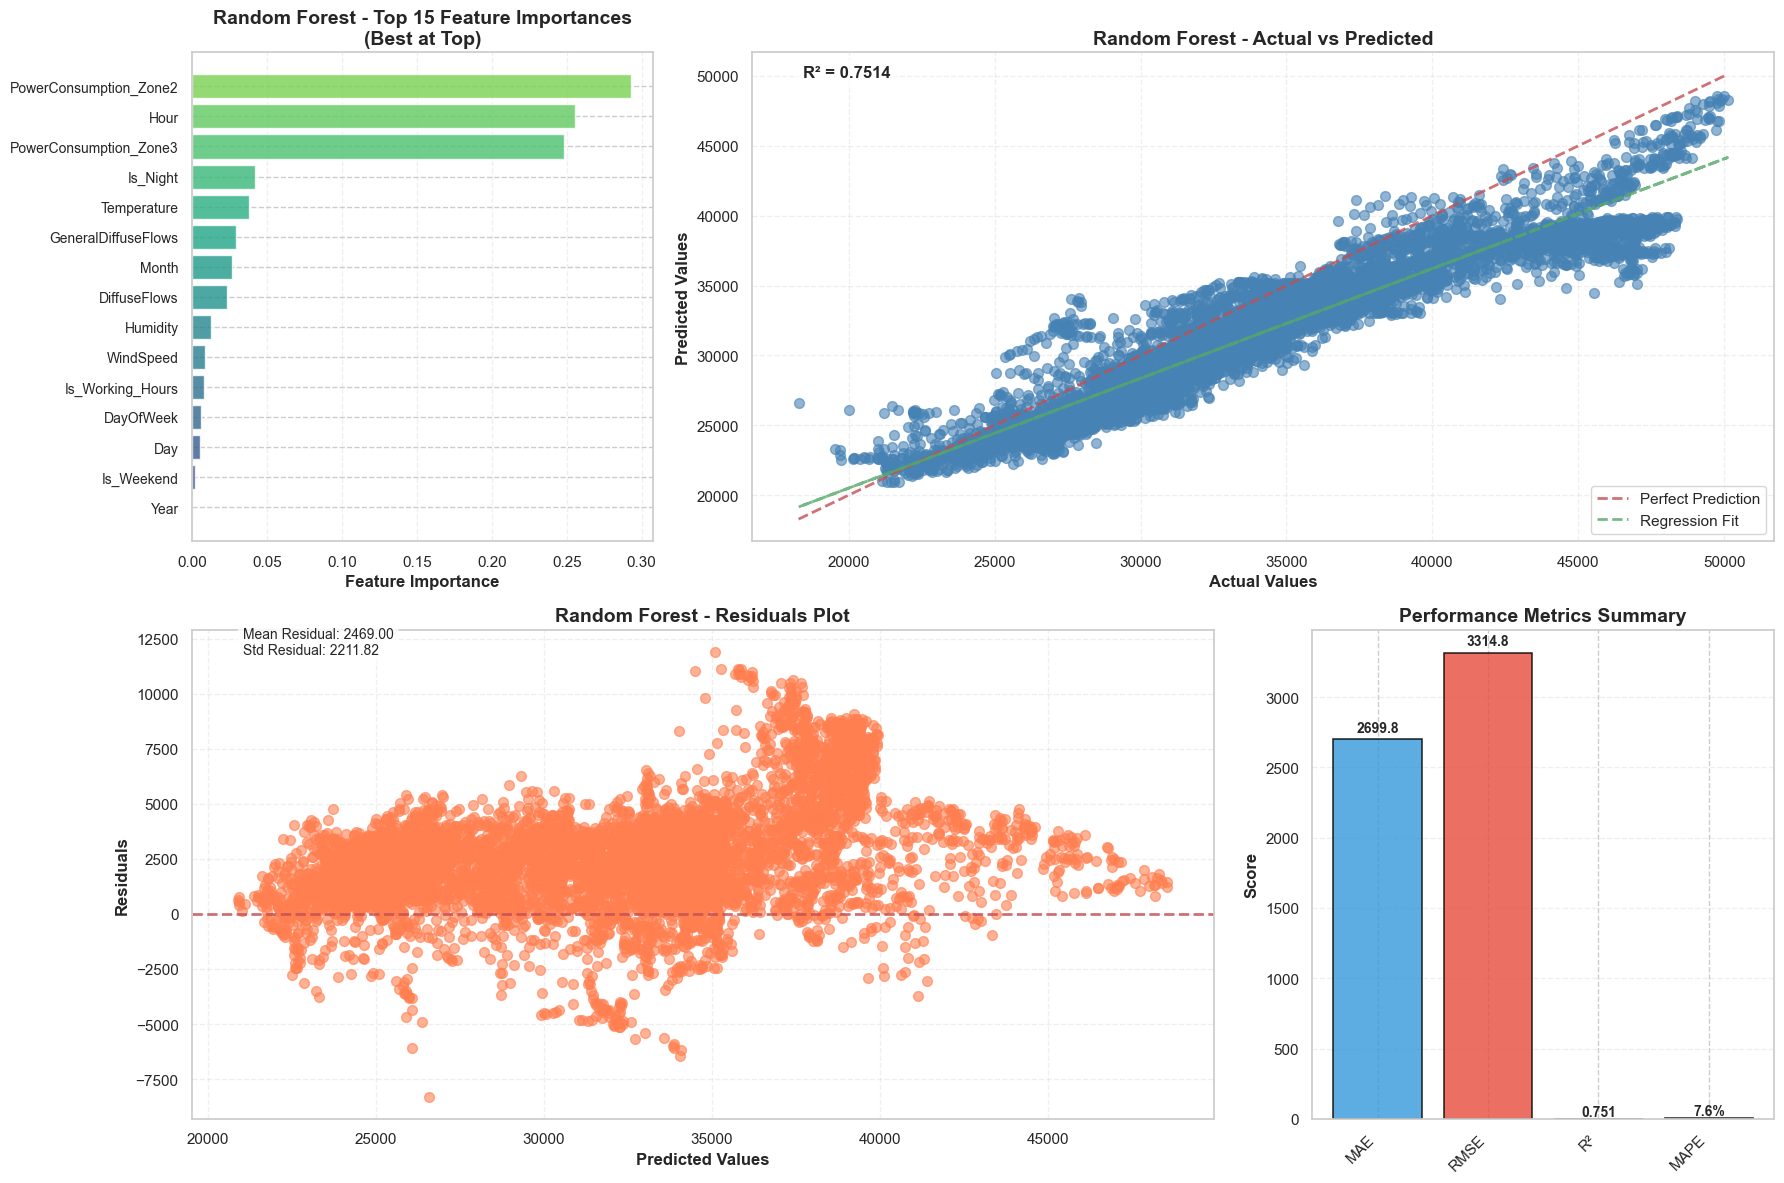


FINAL TEST SET EVALUATION - RANDOM FOREST
Random Forest (Test) Results:
  MAE: 2683.20
  RMSE: 3031.25
  R²: 0.7584
  MAPE: 9.76%
  MBE: 1811.50 (bias: over-prediction)
  Relative RMSE: 10.29%
------------------------------------------------------------

VALIDATION vs TEST PERFORMANCE COMPARISON
RMSE: 3314.8 (Val) → 3031.2 (Test) | Change: -283.6 (-8.6%)
R²:   0.7514 (Val) → 0.7584 (Test) | Change: +0.0069

FINAL SUMMARY
Validation RMSE: 3314.83
Validation R²: 0.7514
Test RMSE: 3031.25
Test R²: 0.7584

RANDOM FOREST - TOP 10 FEATURES
 6. PowerConsumption_Zone2: 0.2931
11. Hour: 0.2553
 7. PowerConsumption_Zone3: 0.2479
14. Is_Night: 0.0424
 1. Temperature: 0.0382
 4. GeneralDiffuseFlows: 0.0298
 9. Month: 0.0271
 5. DiffuseFlows: 0.0237
 2. Humidity: 0.0126
 3. WindSpeed: 0.0085

RANDOM FOREST MODELING COMPLETE


In [28]:

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV

def evaluate_model_advanced(y_true, y_pred, dataset_name=""):
    """Comprehensive model evaluation with additional metrics"""
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    
    # Mean Absolute Percentage Error (MAPE)
    mape = np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), 1e-8))) * 100
    
    # Calculate additional metrics
    mbe = np.mean(y_pred - y_true)  # Mean Bias Error
    relative_rmse = rmse / np.mean(y_true) * 100  # Relative RMSE as percentage
    
    print(f"{dataset_name} Results:")
    print(f"  MAE: {mae:.2f}")
    print(f"  RMSE: {rmse:.2f}")
    print(f"  R²: {r2:.4f}")
    print(f"  MAPE: {mape:.2f}%")
    print(f"  MBE: {mbe:.2f} (bias: {'over' if mbe > 0 else 'under'}-prediction)")
    print(f"  Relative RMSE: {relative_rmse:.2f}%")
    print("-" * 60)
    
    return {
        'MAE': mae, 'RMSE': rmse, 'MSE': mse, 'R2': r2, 
        'MAPE': mape, 'MBE': mbe, 'Relative_RMSE': relative_rmse
    }

def build_random_forest_model(X_train, X_val, X_test, y_train, y_val, y_test, feature_columns):
    """
    Build Random Forest model
    """
    print("=" * 80)
    print("BUILDING RANDOM FOREST MODEL")
    print("=" * 80)
    
    results = {}
    models = {}
    feature_importances = {}
    
    # Random Forest
    print("\n RANDOM FOREST MODEL")
    rf_model = RandomForestRegressor(
        n_estimators=500,
        max_depth=15,
        min_samples_split=2,
        min_samples_leaf=10,
        max_features='sqrt',
        bootstrap=True,
        random_state=42,
        n_jobs=-1
    )
    
    rf_model.fit(X_train, y_train)
    y_val_rf = rf_model.predict(X_val)
    results['Random Forest'] = evaluate_model_advanced(y_val, y_val_rf, "Random Forest (Val)")
    models['Random Forest'] = rf_model
    
    # Feature importance
    feature_importances['Random Forest'] = pd.DataFrame({
        'feature': feature_columns,
        'importance': rf_model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    return results, models, feature_importances

def plot_random_forest_results(results, models, feature_importances, X_val, y_val):
    """Plot comprehensive results for Random Forest with improved visuals"""
    fig = plt.figure(figsize=(18, 12))
    
    # Create grid layout
    gs = plt.GridSpec(2, 3, figure=fig)
    
    # 1. Feature Importance (Top 15 features) - FIXED: Best features at top
    ax1 = fig.add_subplot(gs[0, 0])
    top_features = feature_importances['Random Forest'].head(15)
    
    # Reverse the order to have best features at the top
    top_features = top_features.iloc[::-1]  # This reverses the DataFrame
    
    # Create horizontal bar plot with better colors
    colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(top_features)))
    y_pos = np.arange(len(top_features))
    
    bars = ax1.barh(y_pos, top_features['importance'], color=colors, alpha=0.8)
    
    ax1.set_yticks(y_pos)
    ax1.set_yticklabels(top_features['feature'], fontsize=10)
    ax1.set_xlabel('Feature Importance', fontsize=12, fontweight='bold')
    ax1.set_title('Random Forest - Top 15 Feature Importances\n(Best at Top)', fontsize=14, fontweight='bold')
    

    
    # Add grid for better readability
    ax1.grid(axis='x', alpha=0.3, linestyle='--')
    ax1.set_axisbelow(True)
    
    # 2. Actual vs Predicted - FIXED: No hexbin, always scatter
    ax2 = fig.add_subplot(gs[0, 1:])
    rf_model = models['Random Forest']
    predictions = rf_model.predict(X_val)
    
    # Always use scatter plot (no hexbin)
    scatter = ax2.scatter(y_val, predictions, alpha=0.6, c='steelblue', s=50)
    
    # Perfect prediction line
    ax2.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=2, alpha=0.8, label='Perfect Prediction')
    
    # Add regression line
    z = np.polyfit(y_val, predictions, 1)
    p = np.poly1d(z)
    ax2.plot(y_val, p(y_val), "g--", lw=2, alpha=0.8, label='Regression Fit')
    
    ax2.set_xlabel('Actual Values', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Predicted Values', fontsize=12, fontweight='bold')
    ax2.set_title('Random Forest - Actual vs Predicted', fontsize=14, fontweight='bold')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Add R² value to plot
    r2_val = results['Random Forest']['R2']
    ax2.text(0.05, 0.95, f'R² = {r2_val:.4f}', transform=ax2.transAxes, 
             fontsize=12, fontweight='bold', bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
    
    # 3. Residuals plot - FIXED: No hexbin, always scatter
    ax3 = fig.add_subplot(gs[1, 0:2])
    residuals = y_val - predictions
    
    # Always use scatter plot (no hexbin)
    ax3.scatter(predictions, residuals, alpha=0.6, color='coral', s=50)
    
    ax3.axhline(y=0, color='r', linestyle='--', linewidth=2, alpha=0.8)
    ax3.set_xlabel('Predicted Values', fontsize=12, fontweight='bold')
    ax3.set_ylabel('Residuals', fontsize=12, fontweight='bold')
    ax3.set_title('Random Forest - Residuals Plot', fontsize=14, fontweight='bold')
    ax3.grid(True, alpha=0.3)
    
    # Add residual statistics
    mean_residual = np.mean(residuals)
    std_residual = np.std(residuals)
    ax3.text(0.05, 0.95, f'Mean Residual: {mean_residual:.2f}\nStd Residual: {std_residual:.2f}', 
             transform=ax3.transAxes, fontsize=10, 
             bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
    
    # 4. Performance metrics summary
    ax4 = fig.add_subplot(gs[1, 2])
    metrics = ['MAE', 'RMSE', 'R²', 'MAPE']
    values = [results['Random Forest']['MAE'], 
              results['Random Forest']['RMSE'], 
              results['Random Forest']['R2'], 
              results['Random Forest']['MAPE']]
    
    # Different colors for different metrics
    colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']
    
    bars = ax4.bar(metrics, values, color=colors, alpha=0.8, edgecolor='black', linewidth=1.2)
    ax4.set_title('Performance Metrics Summary', fontsize=14, fontweight='bold')
    ax4.set_ylabel('Score', fontsize=12, fontweight='bold')
    ax4.grid(True, alpha=0.3, axis='y')
    
    # Rotate x-axis labels for better fit
    ax4.set_xticklabels(metrics, rotation=45, ha='right')
    
    # Add value labels on bars with appropriate formatting
    for bar, value, metric in zip(bars, values, metrics):
        height = bar.get_height()
        if metric == 'R²':
            ax4.text(bar.get_x() + bar.get_width()/2, height + 0.01, 
                    f'{value:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=10)
        elif metric == 'MAPE':
            ax4.text(bar.get_x() + bar.get_width()/2, height + 0.1, 
                    f'{value:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=10)
        else:
            ax4.text(bar.get_x() + bar.get_width()/2, height + max(values)*0.01, 
                    f'{value:.1f}', ha='center', va='bottom', fontweight='bold', fontsize=10)
    
    plt.tight_layout()
    plt.show()

def test_random_forest_model(models, results, X_test, y_test, feature_columns):
    """Evaluate Random Forest on test set"""
    print("\n" + "=" * 80)
    print("FINAL TEST SET EVALUATION - RANDOM FOREST")
    print("=" * 80)
    
    rf_model = models['Random Forest']
    y_test_pred = rf_model.predict(X_test)
    test_results = evaluate_model_advanced(y_test, y_test_pred, "Random Forest (Test)")
    
    # Compare validation vs test performance
    print("\n" + "=" * 80)
    print("VALIDATION vs TEST PERFORMANCE COMPARISON")
    print("=" * 80)
    
    val_rmse = results['Random Forest']['RMSE']
    test_rmse = test_results['RMSE']
    val_r2 = results['Random Forest']['R2']
    test_r2 = test_results['R2']
    
    rmse_change = test_rmse - val_rmse
    rmse_change_pct = (rmse_change / val_rmse) * 100
    r2_change = test_r2 - val_r2
    
    print(f"RMSE: {val_rmse:.1f} (Val) → {test_rmse:.1f} (Test) | Change: {rmse_change:+.1f} ({rmse_change_pct:+.1f}%)")
    print(f"R²:   {val_r2:.4f} (Val) → {test_r2:.4f} (Test) | Change: {r2_change:+.4f}")
    
    comparison_data = [{
        'Model': 'Random Forest',
        'Val_RMSE': val_rmse,
        'Test_RMSE': test_rmse,
        'RMSE_Change': rmse_change,
        'RMSE_Change_Pct': rmse_change_pct,
        'Val_R2': val_r2,
        'Test_R2': test_r2,
        'R2_Change': r2_change
    }]
    
    comparison_df = pd.DataFrame(comparison_data)
    
    return test_results, comparison_df

# Main execution
print("=" * 80)
print("RUNNING RANDOM FOREST MODEL")
print("=" * 80)

# Build Random Forest model
results, models, feature_importances = build_random_forest_model(
    X_train, X_val, X_test, y_train, y_val, y_test, features
)

# Plot results
plot_random_forest_results(results, models, feature_importances, X_val, y_val)

# Test model on test set
test_results, final_comparison = test_random_forest_model(models, results, X_test, y_test, features)

# Final summary
print("\n" + "=" * 80)
print("FINAL SUMMARY")
print("=" * 80)
print(f"Validation RMSE: {results['Random Forest']['RMSE']:.2f}")
print(f"Validation R²: {results['Random Forest']['R2']:.4f}")
print(f"Test RMSE: {test_results['RMSE']:.2f}")
print(f"Test R²: {test_results['R2']:.4f}")

# Show feature importances
print("\n" + "=" * 80)
print("RANDOM FOREST - TOP 10 FEATURES")
print("=" * 80)

top_features = feature_importances['Random Forest'].head(10)
for i, row in top_features.iterrows():
    print(f"{i+1:2d}. {row['feature']}: {row['importance']:.4f}")

print("\n" + "=" * 80)
print("RANDOM FOREST MODELING COMPLETE")
print("=" * 80)

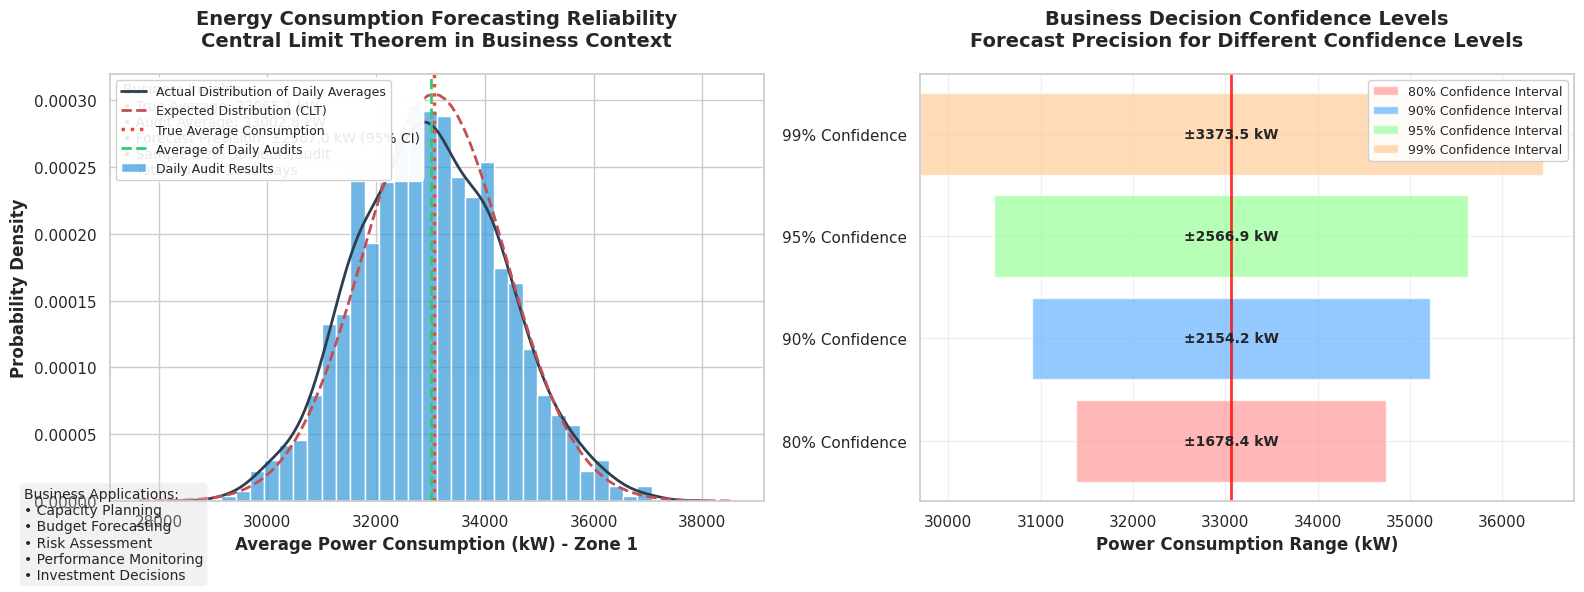

BUSINESS INTELLIGENCE SUMMARY - CENTRAL LIMIT THEOREM APPLICATION
 True Population Mean: 33065.05 kW
 Average of Daily Audits: 33002.76 kW
 Standard Error: 1309.68 kW
 Sample Size per Audit: 30 hourly readings
 Total Audits Conducted: 1000 days

BUSINESS CONFIDENCE INTERVALS:
----------------------------------------
80% Confidence: 33065.1 ± 1678.4 kW
              Range: 31386.6 - 34743.5 kW
90% Confidence: 33065.1 ± 2154.2 kW
              Range: 30910.8 - 35219.3 kW
95% Confidence: 33065.1 ± 2566.9 kW
              Range: 30498.1 - 35632.0 kW
99% Confidence: 33065.1 ± 3373.5 kW
              Range: 29691.5 - 36438.6 kW

KEY BUSINESS INSIGHTS:
----------------------------------------
✓ With 30 hourly readings, we can estimate daily consumption within ±2566.9 kW (95% confidence)
✓ Sample means follow normal distribution regardless of original data shape
✓ Larger samples provide more precise estimates for business planning
✓ Reliable forecasting enables better resource allocation and c

In [29]:
from scipy.stats import norm

# Set professional business style
sns.set_style("whitegrid")
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'

# Business context parameters
n_samples = 1000  # Number of daily energy audits
sample_size = 30  # Number of hourly readings per audit
population_mean = train_data['PowerConsumption_Zone1'].mean()
population_std = train_data['PowerConsumption_Zone1'].std()

# Generate sampling distribution - simulating daily energy audits
sample_means = []
for _ in range(n_samples):
    sample = train_data['PowerConsumption_Zone1'].sample(n=sample_size, replace=True)
    sample_means.append(sample.mean())

# Calculate theoretical CLT parameters for business planning
sem = population_std / np.sqrt(sample_size)  # Standard Error - precision of our estimates

# Create business-focused visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# LEFT PLOT: CLT Demonstration with Business Context
# -------------------------------------------------
ax1 = plt.subplot(1, 2, 1)

# Plot histogram of sample means (daily audit results)
sns.histplot(sample_means, kde=False, bins=30, 
            color='#3498db', alpha=0.7,
            stat='density', label='Daily Audit Results', ax=ax1)

# Plot empirical distribution
sns.kdeplot(sample_means, color='#2c3e50', linewidth=2, 
           label='Actual Distribution of Daily Averages', ax=ax1)

# Plot theoretical normal distribution for forecasting
xmin, xmax = ax1.get_xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, population_mean, sem)
ax1.plot(x, p, 'r--', linewidth=2, label='Expected Distribution (CLT)')

# Add critical business thresholds
ax1.axvline(population_mean, color='#e74c3c', linestyle=':', linewidth=2.5, 
           label='True Average Consumption')
ax1.axvline(np.mean(sample_means), color='#2ecc71', linestyle='--', linewidth=2, 
           label='Average of Daily Audits')

# Business insights annotations
business_insight = (
    f'Business Insights:\n'
    f'• True Average: {population_mean:.1f} kW\n'
    f'• Audit Average: {np.mean(sample_means):.1f} kW\n'
    f'• Forecast Precision: ±{sem*1.96:.1f} kW (95% CI)\n'
    f'• Sample Size: {sample_size} hours/audit\n'
    f'• Total Audits: {n_samples} days'
)

ax1.text(0.02, 0.98, business_insight, transform=ax1.transAxes, 
        ha='left', va='top', fontsize=10,
        bbox=dict(facecolor='white', alpha=0.95, boxstyle='round'))

ax1.set_title('Energy Consumption Forecasting Reliability\n'
             'Central Limit Theorem in Business Context', 
             fontsize=14, pad=20, fontweight='bold')
ax1.set_xlabel('Average Power Consumption (kW) - Zone 1', fontsize=12, fontweight='bold')
ax1.set_ylabel('Probability Density', fontsize=12, fontweight='bold')
ax1.legend(fontsize=9, frameon=True, framealpha=0.9, loc='upper left')

# RIGHT PLOT: Business Decision Implications
# ------------------------------------------
ax2 = plt.subplot(1, 2, 2)

# Create confidence intervals for business decisions
confidence_levels = [80, 90, 95, 99]
z_scores = [norm.ppf(1 - (1 - cl/100)/2) for cl in confidence_levels]
margins_of_error = [z * sem for z in z_scores]

# Plot confidence intervals
colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99']
y_pos = range(len(confidence_levels))

for i, (cl, moe, color) in enumerate(zip(confidence_levels, margins_of_error, colors)):
    ax2.barh(i, 2 * moe, left=population_mean - moe, color=color, alpha=0.7, 
            label=f'{cl}% Confidence Interval')
    ax2.text(population_mean, i, f'±{moe:.1f} kW', 
            ha='center', va='center', fontweight='bold', fontsize=10)

# Format the confidence interval plot
ax2.axvline(population_mean, color='red', linestyle='-', linewidth=2, alpha=0.8)
ax2.set_yticks(y_pos)
ax2.set_yticklabels([f'{cl}% Confidence' for cl in confidence_levels])
ax2.set_xlabel('Power Consumption Range (kW)', fontsize=12, fontweight='bold')
ax2.set_title('Business Decision Confidence Levels\n'
             'Forecast Precision for Different Confidence Levels', 
             fontsize=14, pad=20, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=9, frameon=True, framealpha=0.9)

# Add business context text
decision_context = (
    'Business Applications:\n'
    '• Capacity Planning\n'
    '• Budget Forecasting\n'
    '• Risk Assessment\n'
    '• Performance Monitoring\n'
    '• Investment Decisions'
)

fig.text(0.02, 0.02, decision_context, fontsize=10,
        bbox=dict(facecolor='lightgray', alpha=0.3, boxstyle='round'))

plt.tight_layout()
plt.subplots_adjust(bottom=0.15)
plt.show()

# Print business summary
print("=" * 80)
print("BUSINESS INTELLIGENCE SUMMARY - CENTRAL LIMIT THEOREM APPLICATION")
print("=" * 80)
print(f" True Population Mean: {population_mean:.2f} kW")
print(f" Average of Daily Audits: {np.mean(sample_means):.2f} kW")
print(f" Standard Error: {sem:.2f} kW")
print(f" Sample Size per Audit: {sample_size} hourly readings")
print(f" Total Audits Conducted: {n_samples} days")
print("\n" + "BUSINESS CONFIDENCE INTERVALS:")
print("-" * 40)
for cl, moe in zip(confidence_levels, margins_of_error):
    lower = population_mean - moe
    upper = population_mean + moe
    print(f"{cl}% Confidence: {population_mean:.1f} ± {moe:.1f} kW")
    print(f"              Range: {lower:.1f} - {upper:.1f} kW")
print("\n" + "KEY BUSINESS INSIGHTS:")
print("-" * 40)
print("✓ With 30 hourly readings, we can estimate daily consumption within ±{:.1f} kW (95% confidence)".format(margins_of_error[2]))
print("✓ Sample means follow normal distribution regardless of original data shape")
print("✓ Larger samples provide more precise estimates for business planning")
print("✓ Reliable forecasting enables better resource allocation and cost control")
print("=" * 80)

## Conclusion & Recommendations

### Conclusion
In this project, a **Random Forest Regressor** was developed to forecast power consumption in **Zone 1** of Tetouan City. The model achieved:

- **R² Score:** 0.758 on the test set (explaining 75.8% of variance)  
- **Key Findings:**
  - **Neighboring Zones:** Power consumption in Zones 2 & 3 are the strongest predictors, with Zone 2 being the most important.  
  - **Temporal Patterns:** Hour of day is the second most important predictor, highlighting strong daily cycles.  
  - **Weather Variables:** Showed relatively low importance compared to power and time factors.  
  - **Prediction Bias:** Model tends to over-predict (positive MBE of 1811.5).  
- **Performance:** RMSE improved by 8.6% on the test set vs. validation, indicating good generalization and no overfitting.

### Recommendations
1. **Real-time Coordination:** Implement coordinated load management across all three zones.  
2. **Leverage Temporal Patterns:** Use strong hourly patterns for precise daily forecasting and peak demand management.  
3. **Address Prediction Bias:** Apply post-processing calibration to correct over-prediction.  
4. **Maintain with Rolling Updates:** Retrain quarterly to capture evolving consumption patterns.  
5. **Develop Multi-zone Forecasting:** Build models for Zones 2 & 3 for comprehensive city-wide management.  
6. **Optimize Feature Engineering:** Explore additional time-based features (day of week, holidays) to enhance performance.

### Future Improvements
- **Explore Advanced Models:** Test models like  LSTM networks to potentially improve predictive accuracy.  
- **Incorporate More Data:** Include additional historical data, finer-grained weather metrics, and socio-economic factors to enhance model learning.  
- **Feature Expansion:** Experiment with new derived features (lag features, rolling averages, special events) for better temporal and spatial coverage.  
- **Automated Model Selection:** Implement pipelines for automated hyperparameter tuning and model comparison to continuously improve performance.

**Summary:** This model provides a solid foundation for Tetouan City's energy forecasting, supporting more efficient grid management and resource planning while offering a clear path for future enhancement.
